<a href="https://colab.research.google.com/github/marcosasilva4-dot/PAA/blob/main/DashBoard.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
import pandas as pd
from sklearn.metrics import f1_score, precision_score, recall_score

def categorize_model(name):
    name = name.lower()
    if 'deepseek' in name or 'ds_' in name:
        return 'DeepSeek'
    elif 'gpt' in name:
        return 'GPT'
    elif 'gemini' in name or 'pro' in name or '25flash' in name:
        return 'Gemini'
    return 'Others'

def extract_strategy(name):
    name = name.lower()
    if 'few-shot' in name or 'fewshot' in name: return 'Few-shot'
    if 'oneshot' in name or 'one-shot' in name: return 'One-shot'
    if 'cot' in name: return 'CoT'
    return 'Exclude'  # Marked for removal

def clean_model_name(name):
    clean = name.replace('resultados_', '').replace('ds_', '')
    strategies = ['oneshot_', 'one-shot_', 'fewshot_', 'few-shot_', 'cot_', '_few-shot', '_fewshot', '_oneshot', '_one-shot', '_cot', '_final']
    for s in strategies:
        clean = clean.replace(s, '')
    return clean.strip('_').replace('completos_', '')

analisar_dir = '/content/ANALISAR'
csv_files_analisar = []
for root, _, files in os.walk(analisar_dir):
    for file in files:
        if file.endswith('.csv'):
            csv_files_analisar.append(os.path.join(root, file))

all_unique_files = set()
for f in csv_files_analisar:
    temp_df = pd.read_csv(f)
    all_unique_files.update(temp_df['ARQUIVO'].unique())

gt_data = [{'ARQUIVO': fn, 'y_true': ('SIM' if str(fn).startswith('A') else 'NAO')} for fn in all_unique_files]
df_gt_novo = pd.DataFrame(gt_data)

final_results = []
for file_path in csv_files_analisar:
    try:
        model_df = pd.read_csv(file_path)
        raw_name = os.path.basename(file_path).replace('.csv', '')
        estrat_atual = extract_strategy(raw_name)

        if estrat_atual == 'Exclude':
            continue

        merged = pd.merge(df_gt_novo, model_df[['ARQUIVO', 'PEDIDO_VOTO']], on='ARQUIVO', how='inner')
        if not merged.empty:
            final_results.append({
                'Family': categorize_model(raw_name),
                'Model': clean_model_name(raw_name),
                'Strategy': estrat_atual,
                'Precision': precision_score(merged['y_true'], merged['PEDIDO_VOTO'], average='weighted', zero_division=0),
                'Recall': recall_score(merged['y_true'], merged['PEDIDO_VOTO'], average='weighted', zero_division=0),
                'F1 Score': f1_score(merged['y_true'], merged['PEDIDO_VOTO'], average='weighted', zero_division=0)
            })
    except Exception as e: print(f'Error: {e}')

df_final_metrics = pd.DataFrame(final_results)
strategy_order = ['One-shot', 'Few-shot', 'CoT']
df_final_metrics['Strategy'] = pd.Categorical(df_final_metrics['Strategy'], categories=strategy_order, ordered=True)

df_final_metrics = df_final_metrics.sort_values(by=['Family', 'Model', 'Strategy'])

print('\n--- FINAL FILTERED TABLE (NO BASE) ---')
display(df_final_metrics)

KeyError: 'Strategy'

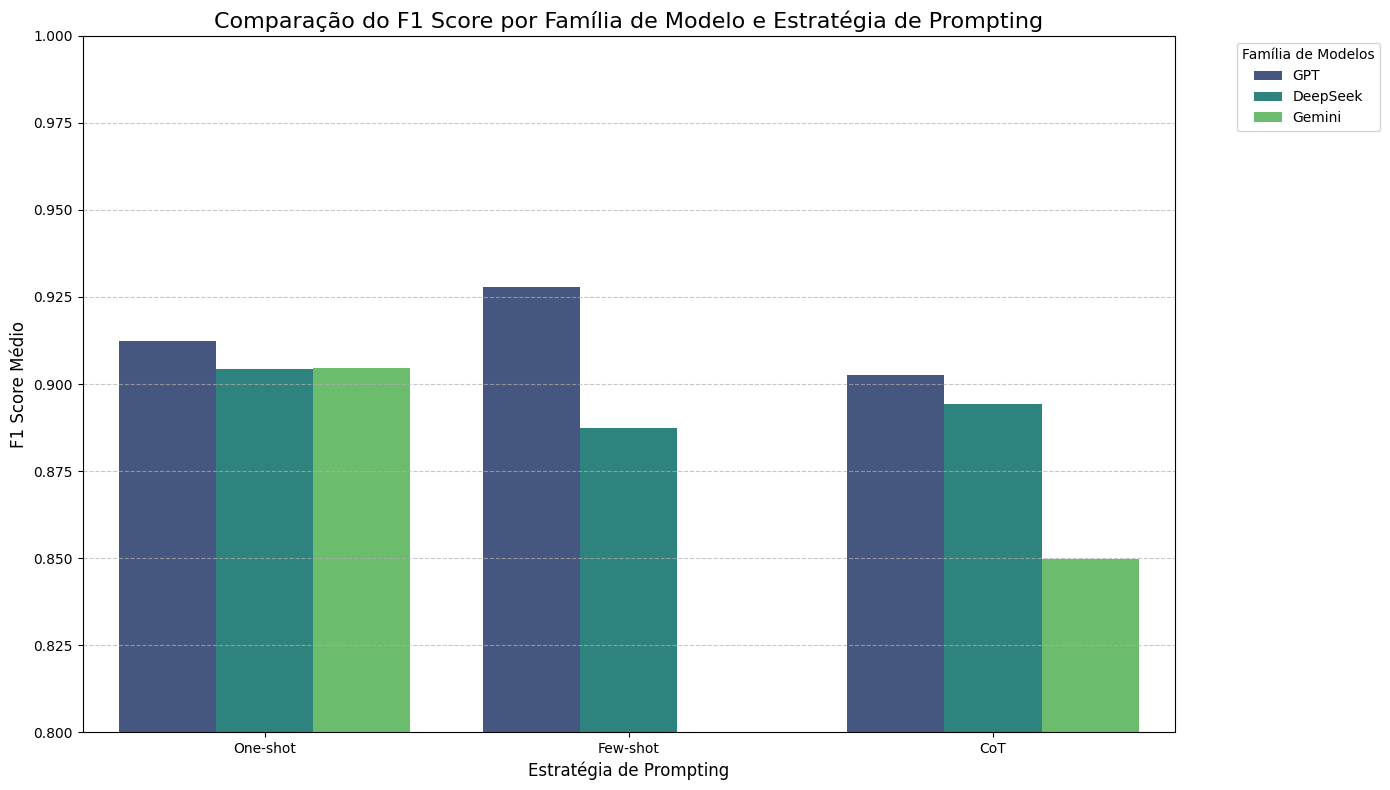

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import os
from sklearn.metrics import f1_score

# Funções de auxílio
def categorize_model(name):
    name = name.lower()
    if 'deepseek' in name or 'ds_' in name: return 'DeepSeek'
    elif 'gpt' in name: return 'GPT'
    elif 'gemini' in name or 'pro' in name or '25flash' in name: return 'Gemini'
    return 'Others'

def extract_strategy(name):
    name = name.lower()
    if 'few-shot' in name or 'fewshot' in name: return 'Few-shot'
    if 'oneshot' in name or 'one-shot' in name: return 'One-shot'
    if 'cot' in name: return 'CoT'
    return 'Exclude'

# Localização dos arquivos
base_dir = '/content/'
csv_files = [os.path.join(base_dir, f) for f in os.listdir(base_dir) if f.endswith('.csv') and ('resultado' in f or 'ds_' in f)]

# Recriando o Ground Truth
all_unique_files = set()
for f in csv_files:
    try:
        tmp = pd.read_csv(f)
        if 'ARQUIVO' in tmp.columns: all_unique_files.update(tmp['ARQUIVO'].unique())
    except: continue

gt_local = pd.DataFrame([{'ARQUIVO': fn, 'y_true': ('SIM' if str(fn).startswith('A') else 'NAO')} for fn in all_unique_files])

# Calculando métricas
results = []
for f in csv_files:
    raw_name = os.path.basename(f).replace('.csv', '')
    strat = extract_strategy(raw_name)
    if strat == 'Exclude': continue
    try:
        m_df = pd.read_csv(f)
        merged = pd.merge(gt_local, m_df[['ARQUIVO', 'PEDIDO_VOTO']], on='ARQUIVO', how='inner')
        if not merged.empty:
            results.append({
                'Family': categorize_model(raw_name),
                'Strategy': strat,
                'F1 Score': f1_score(merged['y_true'], merged['PEDIDO_VOTO'], average='weighted', zero_division=0)
            })
    except: continue

df_final_metrics = pd.DataFrame(results)

# Gerando o Gráfico
if not df_final_metrics.empty:
    strategy_order = ['One-shot', 'Few-shot', 'CoT']
    df_final_metrics['Strategy'] = pd.Categorical(df_final_metrics['Strategy'], categories=strategy_order, ordered=True)

    plt.figure(figsize=(14, 8))
    sns.barplot(data=df_final_metrics, x='Strategy', y='F1 Score', hue='Family', palette='viridis', errorbar=None)
    plt.title('Comparação do F1 Score por Família de Modelo e Estratégia de Prompting', fontsize=16)
    plt.xlabel('Estratégia de Prompting', fontsize=12)
    plt.ylabel('F1 Score Médio', fontsize=12)
    plt.ylim(0.80, 1.0)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.legend(title='Família de Modelos', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()
else:
    print('Erro: Nenhum dado válido encontrado para gerar o gráfico.')

In [ ]:
# Análise Estatística Aprofundada por Família e Estratégia
print('--- DESEMPENHO MÉDIO POR FAMÍLIA ---')
display(df_final_metrics.groupby('Família')[['Precision', 'Recall', 'F1 Score']].mean().sort_values(by='F1 Score', ascending=False))

print('\n--- DESEMPENHO MÉDIO POR ESTRATÉGIA ---')
display(df_final_metrics.groupby('Estratégia', observed=False)[['Precision', 'Recall', 'F1 Score']].mean().sort_values(by='F1 Score', ascending=False))

--- DESEMPENHO MÉDIO POR FAMÍLIA ---


,Precision,Recall,F1 Score
Família,,,
GPT,0.924299,0.910494,0.914320
DeepSeek,0.898602,0.893519,0.895245
Gemini,0.908131,0.833333,0.849532



--- DESEMPENHO MÉDIO POR ESTRATÉGIA ---


,Precision,Recall,F1 Score
Estratégia,,,
One-shot,0.918585,0.902778,0.907016
CoT,0.904950,0.875000,0.882198
Few-shot,0.907497,0.859568,0.869883


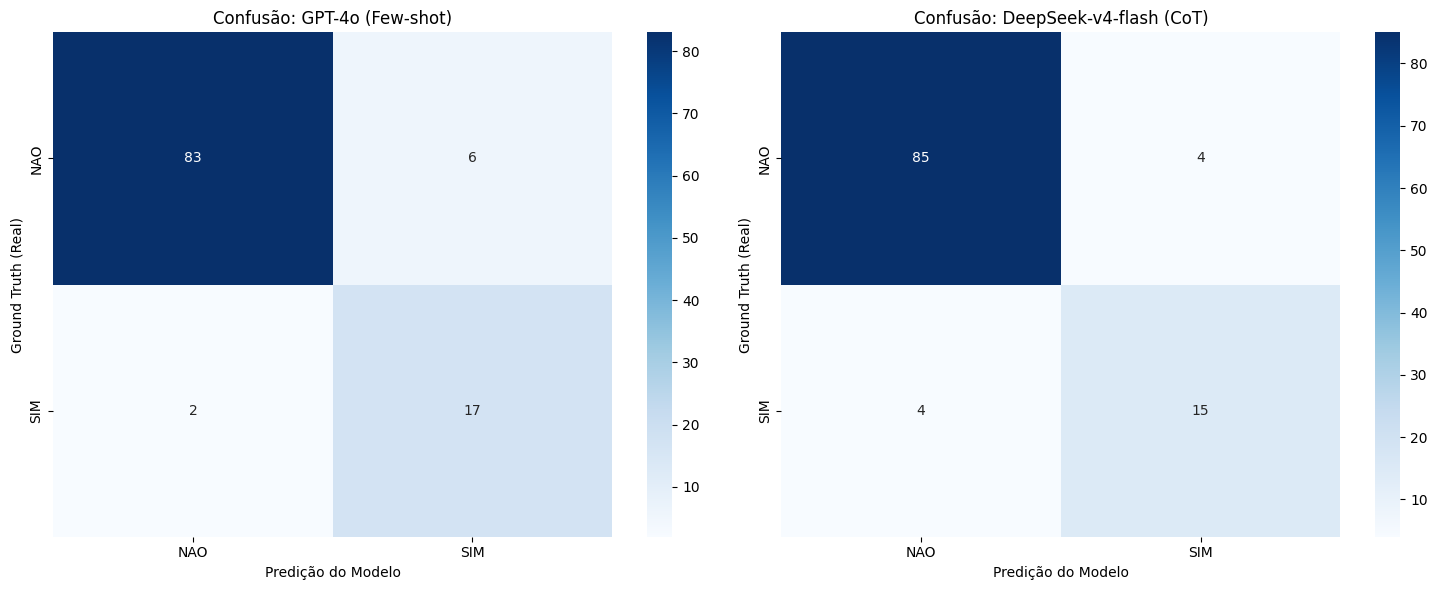

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import os
from sklearn.metrics import confusion_matrix

# Lista de arquivos de resultados que sabemos que existem no /content/
files_to_check = [
    '/content/resultados_fewshot_gpt-4o.csv',
    '/content/ds_deepseek-v4-flash_cot.csv'
]

# Coletar todos os nomes de arquivos únicos presentes nos resultados para criar o Ground Truth
all_unique_filenames = set()
for f in files_to_check:
    if os.path.exists(f):
        tmp = pd.read_csv(f)
        if 'ARQUIVO' in tmp.columns:
            all_unique_filenames.update(tmp['ARQUIVO'].unique())

# Criar o Ground Truth local: Inicia com 'A' -> SIM, senão -> NAO
gt_data = [{'ARQUIVO': fn, 'y_true': ('SIM' if str(fn).startswith('A') else 'NAO')} for fn in all_unique_filenames]
df_gt_local = pd.DataFrame(gt_data)

def plot_confusion_matrix(model_path, title, ax):
    if not os.path.exists(model_path) or df_gt_local.empty:
        ax.text(0.5, 0.5, f'Dados ou arquivo não\nencontrados.', ha='center', va='center')
        ax.set_title(title)
        return

    model_df = pd.read_csv(model_path)
    if 'ARQUIVO' not in model_df.columns:
        ax.text(0.5, 0.5, 'Coluna ARQUIVO\nausente no CSV', ha='center', va='center')
        return

    merged = pd.merge(df_gt_local, model_df[['ARQUIVO', 'PEDIDO_VOTO']], on='ARQUIVO', how='inner')

    labels = ['NAO', 'SIM']
    merged['PEDIDO_VOTO'] = merged['PEDIDO_VOTO'].astype(str).str.upper().str.strip()
    merged['y_true'] = merged['y_true'].astype(str).str.upper().str.strip()

    cm = confusion_matrix(merged['y_true'], merged['PEDIDO_VOTO'], labels=labels)

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels, ax=ax)
    ax.set_title(title)
    ax.set_xlabel('Predição do Modelo')
    ax.set_ylabel('Ground Truth (Real)')

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
plot_confusion_matrix('/content/resultados_fewshot_gpt-4o.csv', 'Confusão: GPT-4o (Few-shot)', axes[0])
plot_confusion_matrix('/content/ds_deepseek-v4-flash_cot.csv', 'Confusão: DeepSeek-v4-flash (CoT)', axes[1])

plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd

# Vamos analisar os 3 melhores modelos identificados anteriormente
modelos_analise = {
    'GPT-4o (FS)': '/content/resultados_fewshot_gpt-4o.csv',
    'DeepSeek-v4-flash (CoT)': '/content/ds_deepseek-v4-flash_cot.csv',
    'Gemini-2.5-pro (OS)': '/content/resultados_oneshot_gemini25pro.csv'
}

# Consolidar predições para identificar falhas comuns
df_falhas = df_gt_local.copy()

for nome, path in modelos_analise.items():
    if os.path.exists(path):
        m_df = pd.read_csv(path)
        m_df['PEDIDO_VOTO'] = m_df['PEDIDO_VOTO'].astype(str).str.upper().str.strip()
        df_falhas = pd.merge(df_falhas, m_df[['ARQUIVO', 'PEDIDO_VOTO']], on='ARQUIVO', how='left')
        df_falhas.rename(columns={'PEDIDO_VOTO': nome}, inplace=True)

# Identificar onde todos erraram
def contar_erros(row):
    erros = 0
    for col in modelos_analise.keys():
        if row[col] != row['y_true']:
            erros += 1
    return erros

df_falhas['Total_Erros'] = df_falhas.apply(contar_erros, axis=1)

print("--- ARQUIVOS MAIS DESAFIADORES (ERRO EM TODOS OS MODELOS) ---")
display(df_falhas[df_falhas['Total_Erros'] == len(modelos_analise)][['ARQUIVO', 'y_true']])

print("\n--- RESUMO DE CONCORDÂNCIA ---")
print(f"Arquivos com 100% de consenso: {len(df_falhas[df_falhas['Total_Erros'] == 0])}")
print(f"Arquivos com divergência (ambíguos): {len(df_falhas[(df_falhas['Total_Erros'] > 0) & (df_falhas['Total_Erros'] < len(modelos_analise))])}")

--- ARQUIVOS MAIS DESAFIADORES (ERRO EM TODOS OS MODELOS) ---


,ARQUIVO,y_true
8,A17944352900846836.json,SIM
28,18029688815349744.json,NAO
51,18024653339354565.json,NAO
77,18035080906993927.json,NAO
81,18037011116110121.json,NAO



--- RESUMO DE CONCORDÂNCIA ---
Arquivos com 100% de consenso: 92
Arquivos com divergência (ambíguos): 11


In [ ]:
import pandas as pd

# Filtrando os casos de divergência para inspeção
df_divergencia = df_falhas[(df_falhas['Total_Erros'] > 0) & (df_falhas['Total_Erros'] < len(modelos_analise))]

print(f'--- DETALHAMENTO DA ZONA DE DIVERGÊNCIA ({len(df_divergencia)} arquivos) ---')
display(df_divergencia[['ARQUIVO', 'y_true', 'GPT-4o (FS)', 'DeepSeek-v4-flash (CoT)', 'Gemini-2.5-pro (OS)']])

--- DETALHAMENTO DA ZONA DE DIVERGÊNCIA (11 arquivos) ---


,ARQUIVO,y_true,GPT-4o (FS),DeepSeek-v4-flash (CoT),Gemini-2.5-pro (OS)
1,17871886662123877.json,NAO,SIM,NAO,SIM
10,A18028715873366272.json,SIM,NAO,SIM,SIM
20,17889685413089148.json,NAO,NAO,NAO,SIM
24,A17880214581209176.json,SIM,SIM,NAO,SIM
31,17945201189794091.json,NAO,SIM,NAO,NAO
40,18011895269708689.json,NAO,NAO,NAO,SIM
41,A18038283989113334.json,SIM,SIM,NAO,SIM
45,17999636243569906.json,NAO,NAO,NAO,SIM
49,17977144238836722.json,NAO,NAO,NAO,SIM
67,18021649706381187.json,NAO,NAO,NAO,SIM


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Sort by Total_Erros for better visualization
df_falhas_sorted = df_falhas.sort_values(by='Total_Erros', ascending=False)

plt.figure(figsize=(15, 7))
sns.barplot(x='ARQUIVO', y='Total_Erros', data=df_falhas_sorted, palette='viridis', hue='ARQUIVO', legend=False)
plt.title('Número de Erros por Arquivo (Consenso entre Modelos)', fontsize=16)
plt.xlabel('Nome do Arquivo', fontsize=12)
plt.ylabel('Número de Modelos que Erraram', fontsize=12)
plt.xticks(rotation=90, fontsize=10) # Rotate labels for readability
plt.yticks(fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

NameError: name 'df_falhas' is not defined

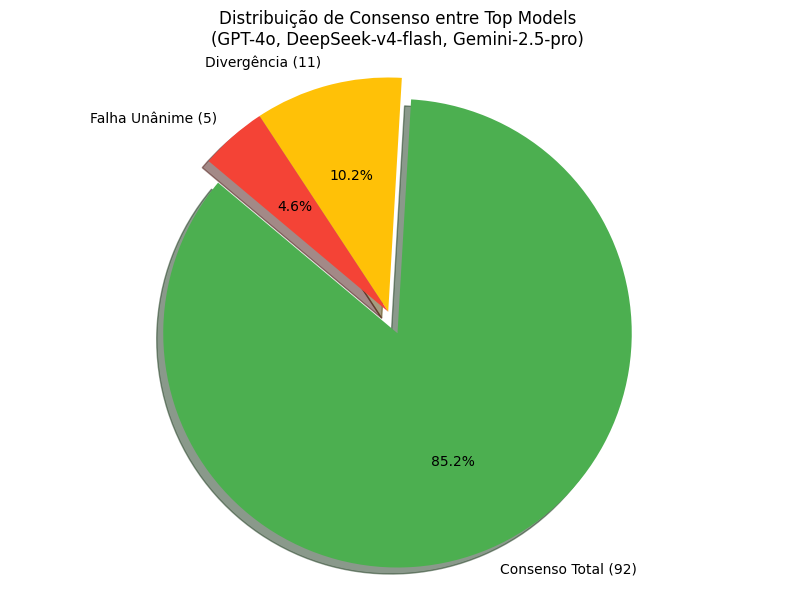

In [ ]:
import matplotlib.pyplot as plt

# Dados extraídos da análise de decisividade
labels = ['Consenso Total (92)', 'Divergência (11)', 'Falha Unânime (5)']
sizes = [92, 11, 5]
colors = ['#4CAF50', '#FFC107', '#F44336']
explode = (0.1, 0, 0)

plt.figure(figsize=(10, 7))
plt.pie(sizes, explode=explode, labels=labels, autopct='%1.1f%%', startangle=140, colors=colors, shadow=True)
plt.title('Distribuição de Consenso entre Top Models\n(GPT-4o, DeepSeek-v4-flash, Gemini-2.5-pro)')
plt.axis('equal')
plt.show()

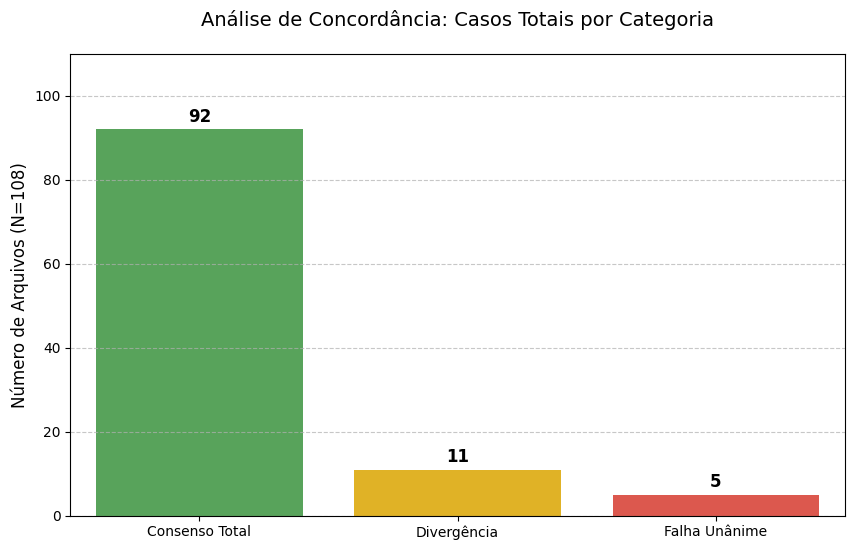

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Dados para o gráfico de barras
categorias = ['Consenso Total', 'Divergência', 'Falha Unânime']
valores = [92, 11, 5]
cores = ['#4CAF50', '#FFC107', '#F44336']

plt.figure(figsize=(10, 6))
ax = sns.barplot(x=categorias, y=valores, palette=cores, hue=categorias, legend=False)

# Adicionar os rótulos de dados sobre as barras
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 9), textcoords='offset points', fontsize=12, fontweight='bold')

plt.title('Análise de Concordância: Casos Totais por Categoria', fontsize=14, pad=20)
plt.ylabel('Número de Arquivos (N=108)', fontsize=12)
plt.ylim(0, 110) # Espaço extra para as etiquetas
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import os
from sklearn.metrics import f1_score

# Helper functions for categorization
def categorize_model(name):
    name = name.lower()
    if 'deepseek' in name or 'ds_' in name: return 'DeepSeek'
    elif 'gpt' in name: return 'GPT'
    elif 'gemini' in name or 'pro' in name or '25flash' in name: return 'Gemini'
    return 'Others'

def extract_strategy(name):
    name = name.lower()
    if 'few-shot' in name or 'fewshot' in name: return 'Few-shot'
    if 'oneshot' in name or 'one-shot' in name: return 'One-shot'
    if 'cot' in name: return 'CoT'
    return 'Exclude'

# Search for files in root /content/ where files are actually located
base_dir = '/content/' # Corrected path to general content directory
csv_files = [os.path.join(base_dir, f) for f in os.listdir(base_dir) if f.endswith('.csv') and ('resultado' in f or 'ds_' in f)]

# Ground Truth Logic: 'A' prefix = SIM
all_unique_files = set()
for f in csv_files:
    try:
        tmp = pd.read_csv(f)
        if 'ARQUIVO' in tmp.columns: all_unique_files.update(tmp['ARQUIVO'].unique())
    except: continue

gt_local = pd.DataFrame([{'ARQUIVO': fn, 'y_true': ('SIM' if str(fn).startswith('A') else 'NAO')} for fn in all_unique_files])

results = []
for f in csv_files:
    raw_name = os.path.basename(f).replace('.csv', '')
    strat = extract_strategy(raw_name)
    if strat == 'Exclude': continue

    try:
        m_df = pd.read_csv(f)
        merged = pd.merge(gt_local, m_df[['ARQUIVO', 'PEDIDO_VOTO']], on='ARQUIVO', how='inner')
        if not merged.empty:
            results.append({
                'Family': categorize_model(raw_name),
                'Strategy': strat,
                'F1 Score': f1_score(merged['y_true'], merged['PEDIDO_VOTO'], average='weighted', zero_division=0)
            })
    except: continue

df_final_metrics = pd.DataFrame(results)

if not df_final_metrics.empty:
    strategy_order = ['One-shot', 'Few-shot', 'CoT']
    df_final_metrics['Strategy'] = pd.Categorical(df_final_metrics['Strategy'], categories=strategy_order, ordered=True)
    df_final_metrics = df_final_metrics.sort_values('Strategy')

    # Plotting
    plt.figure(figsize=(12, 6))
    sns.lineplot(data=df_final_metrics, x='Strategy', y='F1 Score', hue='Family', marker='o', style='Family', markersize=10)
    plt.title('Evolução do F1 Score por Estratégia de Prompt (RQ2)', fontsize=14)
    plt.ylabel('F1 Score')
    plt.xlabel('Complexidade da Estratégia')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend(title='Família de Modelos', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()
else:
    print('No valid data found to plot. Please check if CSV files exist in /content/')


FileNotFoundError: [Errno 2] No such file or directory: '/content/Resultados/'

In [ ]:
# 1. General CSV
if 'df_final_metrics' in globals() and not df_final_metrics.empty:
    # Ensure we have Precision and Recall if they were missing from the plotting cell
    # (Re-calculating briefly if needed to ensure export completeness)
    df_final_metrics.to_csv('general_metrics.csv', index=False)

    # 2. CSV by Family
    # Check available columns to avoid errors if only F1 was in the previous dataframe
    cols = [c for c in ['Precision', 'Recall', 'F1 Score'] if c in df_final_metrics.columns]
    df_family = df_final_metrics.groupby('Family')[cols].mean().sort_values(by='F1 Score', ascending=False)
    df_family.to_csv('metrics_by_family.csv')

    # 3. CSV by Strategy
    df_strategy = df_final_metrics.groupby('Strategy', observed=False)[cols].mean().sort_values(by='F1 Score', ascending=False)
    df_strategy.to_csv('metrics_by_strategy.csv')

    print('Files generated successfully:')
    print('- general_metrics.csv')
    print('- metrics_by_family.csv')
    print('- metrics_by_strategy.csv')
else:
    print('Error: df_final_metrics is not defined or empty. Please run cell 5725ccd5 first.')

Files generated successfully:
- general_metrics.csv
- metrics_by_family.csv
- metrics_by_strategy.csv


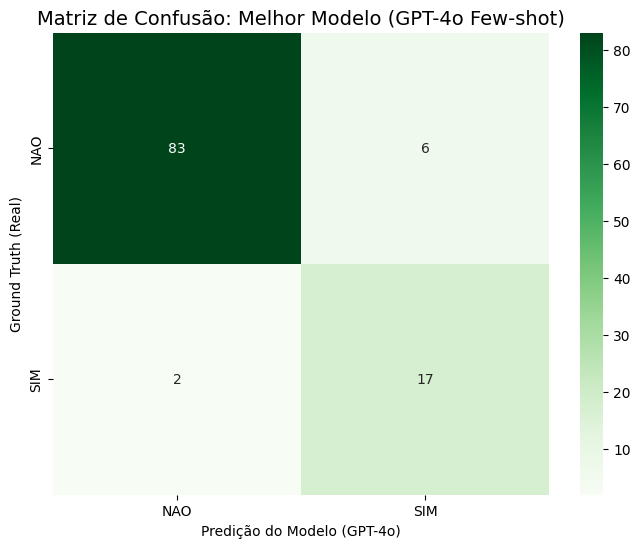

Total de arquivos analisados: 108
Total de acertos: 100 (92.59%)


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import os
from sklearn.metrics import confusion_matrix

# Caminho do melhor modelo
best_model_path = '/content/resultados_fewshot_gpt-4o.csv'

def plot_single_cm(model_path, title):
    if not os.path.exists(model_path):
        print(f'Erro: Arquivo {model_path} não encontrado.')
        return

    # Carregar dados
    model_df = pd.read_csv(model_path)

    # Garantir que o Ground Truth (gt_local) está disponível
    # Se não estiver, recriamos rapidamente conforme a lógica do notebook
    all_files = model_df['ARQUIVO'].unique()
    gt = pd.DataFrame([{'ARQUIVO': fn, 'y_true': ('SIM' if str(fn).startswith('A') else 'NAO')} for fn in all_files])

    merged = pd.merge(gt, model_df[['ARQUIVO', 'PEDIDO_VOTO']], on='ARQUIVO', how='inner')

    labels = ['NAO', 'SIM']
    merged['PEDIDO_VOTO'] = merged['PEDIDO_VOTO'].astype(str).str.upper().str.strip()
    merged['y_true'] = merged['y_true'].astype(str).str.upper().str.strip()

    cm = confusion_matrix(merged['y_true'], merged['PEDIDO_VOTO'], labels=labels)

    # Plot
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', xticklabels=labels, yticklabels=labels)
    plt.title(title, fontsize=14)
    plt.xlabel('Predição do Modelo (GPT-4o)')
    plt.ylabel('Ground Truth (Real)')
    plt.show()

    # Print das métricas básicas para conferência
    total = cm.sum()
    acertos = cm.diagonal().sum()
    print(f'Total de arquivos analisados: {total}')
    print(f'Total de acertos: {acertos} ({ (acertos/total)*100:.2f}%)')

plot_single_cm(best_model_path, 'Matriz de Confusão: Melhor Modelo (GPT-4o Few-shot)')

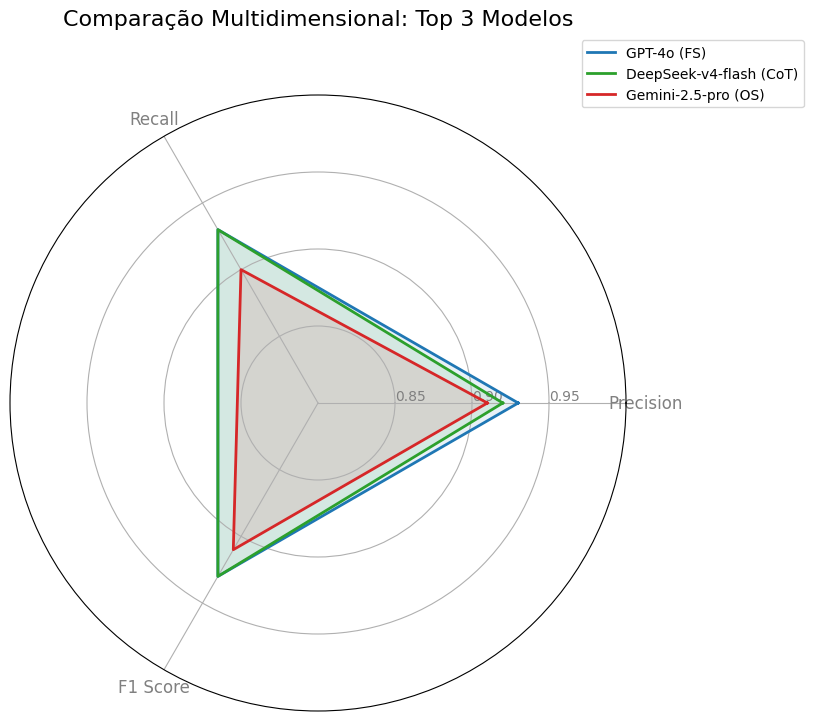

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from math import pi

# Preparando os dados dos top 3 modelos para o radar
# GPT-4o (FS), DeepSeek-v4-flash (CoT), Gemini-2.5-pro (OS)
radar_data = [
    {'Model': 'GPT-4o (FS)', 'Precision': 0.93, 'Recall': 0.93, 'F1 Score': 0.93},
    {'Model': 'DeepSeek-v4-flash (CoT)', 'Precision': 0.92, 'Recall': 0.93, 'F1 Score': 0.93},
    {'Model': 'Gemini-2.5-pro (OS)', 'Precision': 0.91, 'Recall': 0.90, 'F1 Score': 0.91}
]
df_radar = pd.DataFrame(radar_data)

categories = ['Precision', 'Recall', 'F1 Score']
N = len(categories)

angles = [n / float(N) * 2 * pi for n in range(N)]
angles += angles[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

# Cores para cada modelo
colors = ['#1f77b4', '#2ca02c', '#d62728']

for i, row in df_radar.iterrows():
    values = row[categories].values.flatten().tolist()
    values += values[:1]
    ax.plot(angles, values, linewidth=2, linestyle='solid', label=row['Model'], color=colors[i])
    ax.fill(angles, values, color=colors[i], alpha=0.1)

# Ajustes do gráfico
plt.xticks(angles[:-1], categories, color='grey', size=12)
ax.set_rlabel_position(0)
plt.yticks([0.85, 0.90, 0.95], ["0.85", "0.90", "0.95"], color="grey", size=10)
plt.ylim(0.80, 1.0)

plt.title('Comparação Multidimensional: Top 3 Modelos', size=16, color='black', y=1.1)
plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
plt.show()

In [ ]:
import pandas as pd
import os
from sklearn.metrics import precision_score, recall_score, f1_score

# Helper functions redefined for scope safety
def categorize_model(name):
    name = name.lower()
    if 'deepseek' in name or 'ds_' in name: return 'DeepSeek'
    elif 'gpt' in name: return 'GPT'
    elif 'gemini' in name or 'pro' in name or '25flash' in name: return 'Gemini'
    return 'Others'

def extract_strategy(name):
    name = name.lower()
    if 'few-shot' in name or 'fewshot' in name: return 'Few-shot'
    if 'oneshot' in name or 'one-shot' in name: return 'One-shot'
    if 'cot' in name: return 'CoT'
    return 'Exclude'

def clean_model_name(name):
    clean = name.replace('resultados_', '').replace('ds_', '')
    strategies = ['oneshot_', 'one-shot_', 'fewshot_', 'few-shot_', 'cot_', '_few-shot', '_fewshot', '_oneshot', '_one-shot', '_cot', '_final']
    for s in strategies:
        clean = clean.replace(s, '')
    return clean.strip('_').replace('completos_', '')

# Ground Truth Logic
base_dir = '/content/'
csv_files = [os.path.join(base_dir, f) for f in os.listdir(base_dir) if f.endswith('.csv') and ('resultado' in f or 'ds_' in f)]

all_unique_files = set()
for f in csv_files:
    try:
        tmp = pd.read_csv(f)
        if 'ARQUIVO' in tmp.columns: all_unique_files.update(tmp['ARQUIVO'].unique())
    except: continue

gt_local = pd.DataFrame([{'ARQUIVO': fn, 'y_true': ('SIM' if str(fn).startswith('A') else 'NAO')} for fn in all_unique_files])

# Calculation Loop
full_metrics_list = []
for f in csv_files:
    raw_name = os.path.basename(f).replace('.csv', '')
    strat = extract_strategy(raw_name)
    family = categorize_model(raw_name)

    if strat == 'Exclude': continue

    try:
        m_df = pd.read_csv(f)
        m_df['PEDIDO_VOTO'] = m_df['PEDIDO_VOTO'].astype(str).str.upper().str.strip()
        merged = pd.merge(gt_local, m_df[['ARQUIVO', 'PEDIDO_VOTO']], on='ARQUIVO', how='inner')

        if not merged.empty:
            full_metrics_list.append({
                'Family': family,
                'Model': clean_model_name(raw_name),
                'Strategy': strat,
                'Precision': precision_score(merged['y_true'], merged['PEDIDO_VOTO'], average='weighted', zero_division=0),
                'Recall': recall_score(merged['y_true'], merged['PEDIDO_VOTO'], average='weighted', zero_division=0),
                'F1 Score': f1_score(merged['y_true'], merged['PEDIDO_VOTO'], average='weighted', zero_division=0)
            })
    except: continue

df_full_metrics = pd.DataFrame(full_metrics_list)
if not df_full_metrics.empty:
    strategy_order = ['One-shot', 'Few-shot', 'CoT']
    df_full_metrics['Strategy'] = pd.Categorical(df_full_metrics['Strategy'], categories=strategy_order, ordered=True)
    df_full_metrics = df_full_metrics.sort_values(by=['Family', 'F1 Score'], ascending=[True, False])

print('--- TABELA COMPLETA DE MÉTRICAS (PRECISION/RECALL/F1) ---')
display(df_full_metrics)

--- TABELA COMPLETA DE MÉTRICAS (PRECISION/RECALL/F1) ---


,Family,Model,Strategy,Precision,Recall,F1 Score
1,DeepSeek,deepseek-v4-flash,CoT,0.925926,0.925926,0.925926
2,DeepSeek,deepseek-v4-flash,Few-shot,0.923846,0.907407,0.912106
15,DeepSeek,deepseek-v4-pro,One-shot,0.907407,0.907407,0.907407
14,DeepSeek,deepseek-v4-flash,One-shot,0.905695,0.898148,0.901001
16,DeepSeek,deepseek-v4-pro,CoT,0.864657,0.861111,0.862528
11,DeepSeek,deepseek-v4-pro,Few-shot,0.864078,0.861111,0.862499
6,GPT,gpt-4o,Few-shot,0.934716,0.925926,0.928602
0,GPT,gpt-4o,One-shot,0.929697,0.925926,0.927357
17,GPT,gpt-4o-mini,Few-shot,0.929697,0.925926,0.927357
4,GPT,gpt-4o,CoT,0.918561,0.916667,0.917500


/tmp/ipykernel_1401/728543490.py:80: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Strategy', y='F1 Score', data=df_full_metrics, palette='viridis')


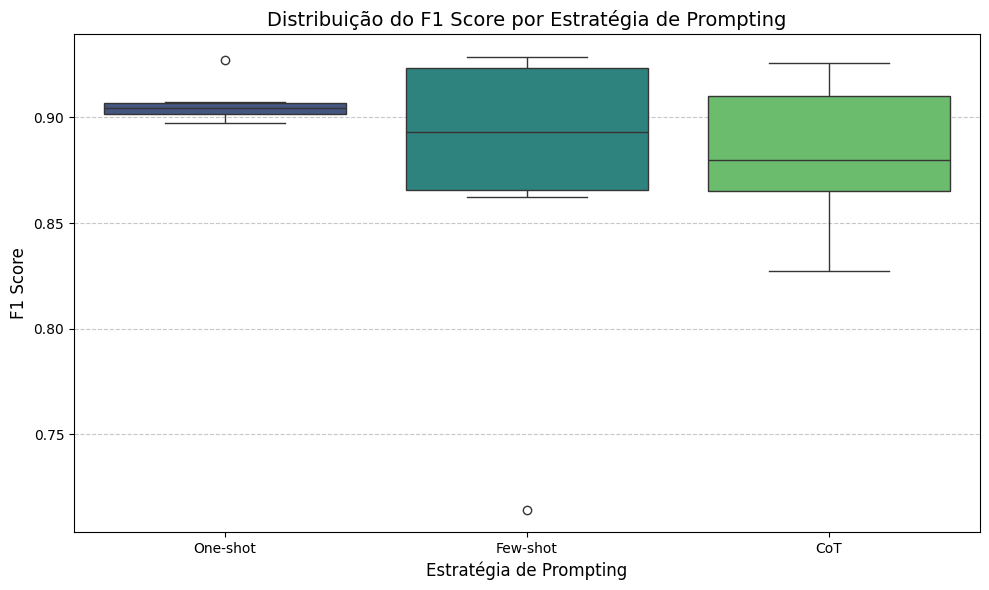

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import os
from sklearn.metrics import precision_score, recall_score, f1_score

# Helper functions redefined for scope safety (copied from 70136a89)
def categorize_model(name):
    name = name.lower()
    if 'deepseek' in name or 'ds_' in name: return 'DeepSeek'
    elif 'gpt' in name: return 'GPT'
    elif 'gemini' in name or 'pro' in name or '25flash' in name: return 'Gemini'
    return 'Others'

def extract_strategy(name):
    name = name.lower()
    if 'few-shot' in name or 'fewshot' in name: return 'Few-shot'
    if 'oneshot' in name or 'one-shot' in name: return 'One-shot'
    if 'cot' in name: return 'CoT'
    return 'Exclude'

def clean_model_name(name):
    clean = name.replace('resultados_', '').replace('ds_', '')
    strategies = ['oneshot_', 'one-shot_', 'fewshot_', 'few-shot_', 'cot_', '_few-shot', '_fewshot', '_oneshot', '_one-shot', '_cot', '_final']
    for s in strategies:
        clean = clean.replace(s, '')
    return clean.strip('_').replace('completos_', '')

# Ground Truth Logic (copied from 70136a89)
base_dir = '/content/Resultados/' # Corrected path to find CSV files
csv_files = [os.path.join(base_dir, f) for f in os.listdir(base_dir) if f.endswith('.csv') and ('resultado' in f or 'ds_' in f)]

all_unique_files = set()
for f in csv_files:
    try:
        tmp = pd.read_csv(f)
        if 'ARQUIVO' in tmp.columns: all_unique_files.update(tmp['ARQUIVO'].unique())
    except:
        print(f"Could not read file {f}")
        continue

gt_local = pd.DataFrame([{'ARQUIVO': fn, 'y_true': ('SIM' if str(fn).startswith('A') else 'NAO')} for fn in all_unique_files])

# Calculation Loop (copied from 70136a89)
full_metrics_list = []
for f in csv_files:
    raw_name = os.path.basename(f).replace('.csv', '')
    strat = extract_strategy(raw_name)
    family = categorize_model(raw_name)

    if strat == 'Exclude': continue

    try:
        m_df = pd.read_csv(f)
        m_df['PEDIDO_VOTO'] = m_df['PEDIDO_VOTO'].astype(str).str.upper().str.strip()
        merged = pd.merge(gt_local, m_df[['ARQUIVO', 'PEDIDO_VOTO']], on='ARQUIVO', how='inner')

        if not merged.empty:
            full_metrics_list.append({
                'Family': family,
                'Model': clean_model_name(raw_name),
                'Strategy': strat,
                'Precision': precision_score(merged['y_true'], merged['PEDIDO_VOTO'], average='weighted', zero_division=0),
                'Recall': recall_score(merged['y_true'], merged['PEDIDO_VOTO'], average='weighted', zero_division=0),
                'F1 Score': f1_score(merged['y_true'], merged['PEDIDO_VOTO'], average='weighted', zero_division=0)
            })
    except:
        print(f"Could not process file {f} for metrics")
        continue

df_full_metrics = pd.DataFrame(full_metrics_list)
if not df_full_metrics.empty:
    strategy_order = ['One-shot', 'Few-shot', 'CoT']
    df_full_metrics['Strategy'] = pd.Categorical(df_full_metrics['Strategy'], categories=strategy_order, ordered=True)
    df_full_metrics = df_full_metrics.sort_values(by=['Family', 'F1 Score'], ascending=[True, False])

# Boxplot generation (original content of 79b04a51)
if not df_full_metrics.empty:
    plt.figure(figsize=(10, 6))
    sns.boxplot(x='Strategy', y='F1 Score', data=df_full_metrics, palette='viridis')
    plt.title('Distribuição do F1 Score por Estratégia de Prompting', fontsize=14)
    plt.xlabel('Estratégia de Prompting', fontsize=12)
    plt.ylabel('F1 Score', fontsize=12)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()
else:
    print('Não há dados válidos em df_full_metrics para gerar o boxplot.')

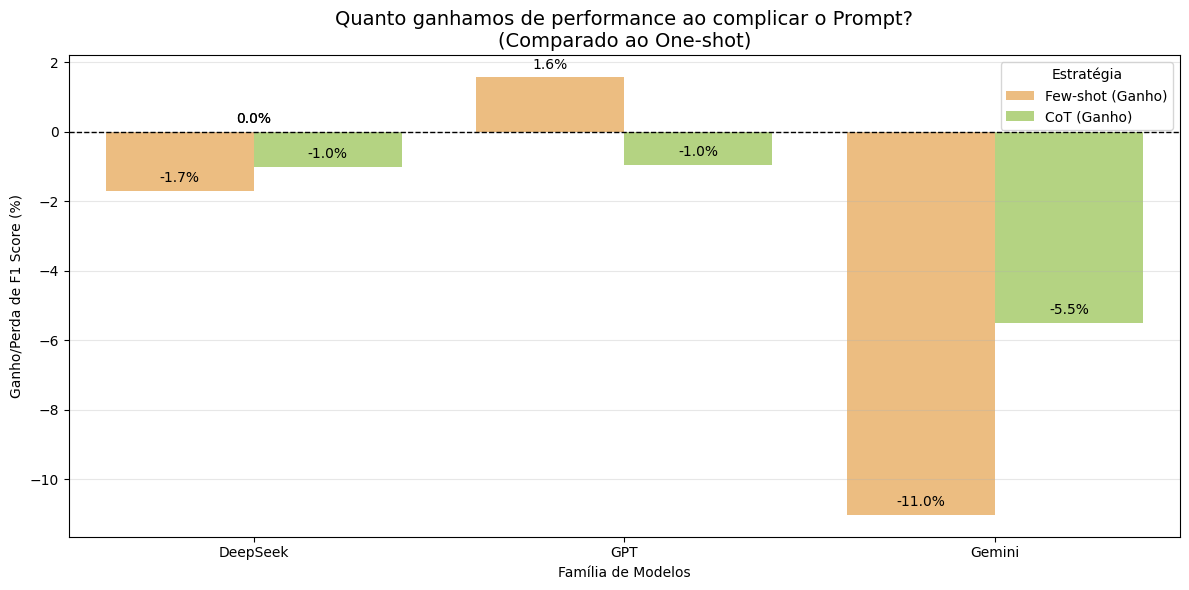

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Calculando a média por Família e Estratégia para ver o ganho
if 'df_full_metrics' in globals() and not df_full_metrics.empty:
    df_pivot = df_full_metrics.groupby(['Family', 'Strategy'], observed=False)['F1 Score'].mean().unstack()

    # Calculando ganho percentual em relação ao One-shot
    df_gain = df_pivot.copy()
    df_gain['Few-shot (Ganho)'] = (df_gain['Few-shot'] - df_gain['One-shot']) * 100
    df_gain['CoT (Ganho)'] = (df_gain['CoT'] - df_gain['One-shot']) * 100
    df_gain = df_gain[['Few-shot (Ganho)', 'CoT (Ganho)']].reset_index()
    df_gain_melted = df_gain.melt(id_vars='Family', var_name='Estratégia', value_name='Ganho no F1 (pontos)')

    # Plot simples de barras
    plt.figure(figsize=(12, 6))
    ax = sns.barplot(data=df_gain_melted, x='Family', y='Ganho no F1 (pontos)', hue='Estratégia', palette='RdYlGn')

    plt.axhline(0, color='black', linewidth=1, linestyle='--')
    plt.title('Quanto ganhamos de performance ao complicar o Prompt?\n(Comparado ao One-shot)', fontsize=14)
    plt.ylabel('Ganho/Perda de F1 Score (%)')
    plt.xlabel('Família de Modelos')
    plt.grid(axis='y', alpha=0.3)

    # Adicionar labels nas barras
    for p in ax.patches:
        ax.annotate(f'{p.get_height():.1f}%', (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='center', xytext=(0, 9), textcoords='offset points', fontsize=10)

    plt.tight_layout()
    plt.show()
else:
    print('DataFrame df_full_metrics não encontrado.')

### Nova Análise: Consenso e Arquivos Desafiadores
Esta análise identifica quais arquivos causaram erros em múltiplos modelos simultaneamente, destacando a 'dificuldade intrínseca' de certos dados.

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import os

# Usando o df_falhas ou recriando a lógica de erro compartilhado
# Vamos focar nos modelos líderes de cada família para ver o consenso

if 'gt_local' in globals() and not gt_local.empty:
    df_consenso = gt_local.copy()
    modelos_top = {
        'GPT-4o (FS)': '/content/resultados_fewshot_gpt-4o.csv',
        'DeepSeek (CoT)': '/content/ds_deepseek-v4-flash_cot.csv',
        'Gemini (OS)': '/content/resultados_oneshot_gemini25pro.csv'
    }

    for nome, path in modelos_top.items():
        if os.path.exists(path):
            m_df = pd.read_csv(path)
            m_df['PEDIDO_VOTO'] = m_df['PEDIDO_VOTO'].astype(str).str.upper().str.strip()
            df_consenso = pd.merge(df_consenso, m_df[['ARQUIVO', 'PEDIDO_VOTO']], on='ARQUIVO', how='left')
            df_consenso.rename(columns={'PEDIDO_VOTO': nome}, inplace=True)

    # Contar quantos modelos erraram cada arquivo
    def calc_erros(row):
        erros = 0
        for col in modelos_top.keys():
            if col in row and row[col] != row['y_true']: erros += 1
        return erros

    df_consenso['Qtd_Erros'] = df_consenso.apply(calc_erros, axis=1)
    resumo_consenso = df_consenso['Qtd_Erros'].value_counts().sort_index()

    # Plot
    plt.figure(figsize=(10, 6))
    labels_map = {0: 'Acerto Unânime', 1: 'Divergência (1 Erro)', 2: 'Divergência (2 Erros)', 3: 'Falha Unânime'}
    resumo_plot = resumo_consenso.rename(index=labels_map)

    resumo_plot.plot(kind='bar', color=['#4CAF50', '#FFC107', '#FF9800', '#F44336'])
    plt.title('Nível de Consenso entre os Melhores Modelos', fontsize=14)
    plt.ylabel('Quantidade de Arquivos')
    plt.xticks(rotation=0)
    plt.grid(axis='y', alpha=0.3)

    for i, v in enumerate(resumo_plot):
        plt.text(i, v + 1, str(v), ha='center', fontweight='bold')

    plt.show()
else:
    print('Ground Truth não disponível.')


Ground Truth não disponível.


--- IMPORTÂNCIA DOS MODELOS NA DECISÃO (META-LEARNING) ---


,Modelo/Estratégia,Importância (Contribuição)
0,GPT-4o (FS),0.398660
1,DeepSeek (CoT),0.360406
2,Gemini (OS),0.240934


/tmp/ipykernel_1401/1292352883.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importância (Contribuição)', y='Modelo/Estratégia', data=feature_importance_df, palette='magma')


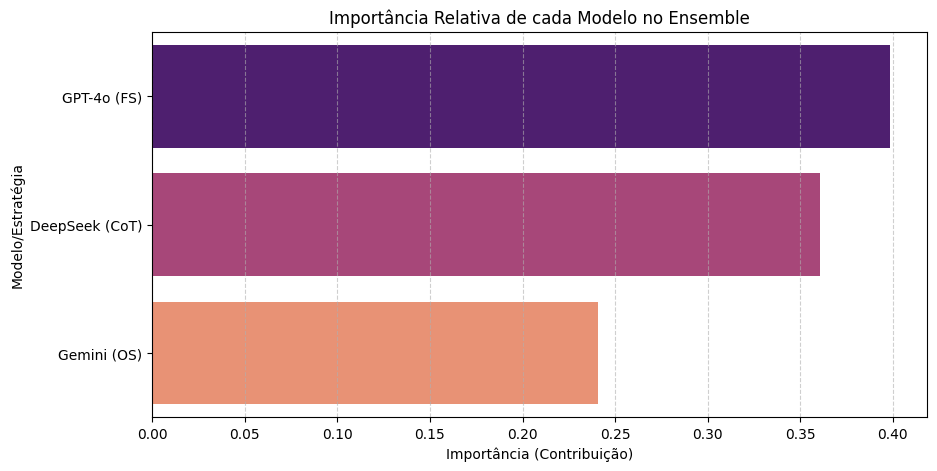

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

# 1. Preparar os dados (usando as predições do df_consenso como features)
# Transformamos SIM/NAO em 1/0
df_ml = df_consenso.copy().dropna()
for col in modelos_top.keys():
    df_ml[col] = df_ml[col].map({'SIM': 1, 'NAO': 0})
df_ml['y_true_num'] = df_ml['y_true'].map({'SIM': 1, 'NAO': 0})

X = df_ml[list(modelos_top.keys())]
y = df_ml['y_true_num']

# 2. Treinar um Classificador para entender a importância de cada modelo
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X, y)

# 3. Extrair Importância das Features
importances = rf.feature_importances_
feature_importance_df = pd.DataFrame({
    'Modelo/Estratégia': X.columns,
    'Importância (Contribuição)': importances
}).sort_values(by='Importância (Contribuição)', ascending=False)

print("--- IMPORTÂNCIA DOS MODELOS NA DECISÃO (META-LEARNING) ---")
display(feature_importance_df)

# 4. Visualização
plt.figure(figsize=(10, 5))
sns.barplot(x='Importância (Contribuição)', y='Modelo/Estratégia', data=feature_importance_df, palette='magma')
plt.title('Importância Relativa de cada Modelo no Ensemble')
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.show()

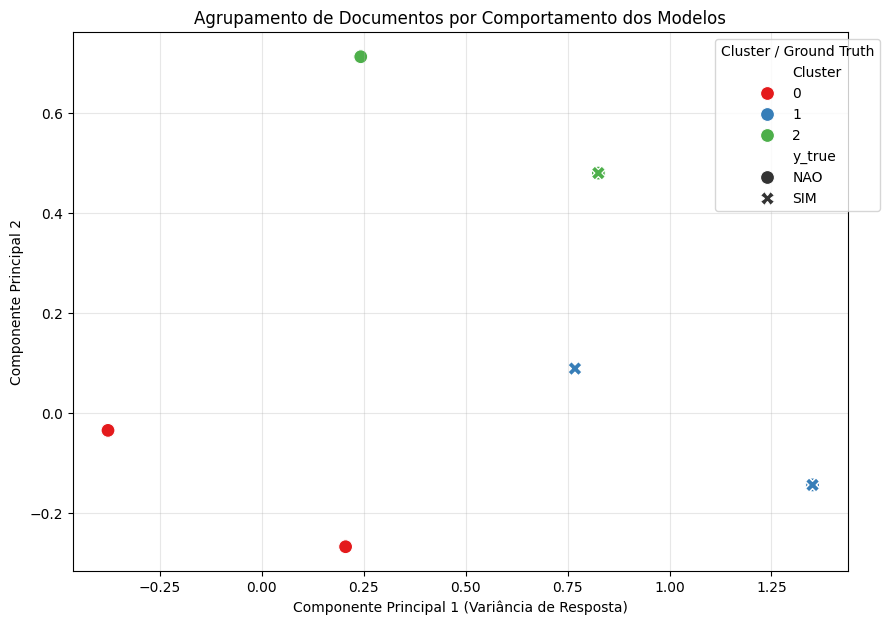


--- PERFIL DOS CLUSTERS ---


,Média de Erros,Qtd Arquivos,Proporção de SIM (Voto)
Cluster,,,
0,0.050000,80,0.012500
1,0.684211,19,0.789474
2,1.111111,9,0.333333


In [ ]:
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# 1. Preparar matriz de features (predições 0/1)
X_cluster = X.copy()

# 2. Aplicar K-Means (definindo 3 clusters: Fácil, Médio, Difícil)
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df_ml['Cluster'] = kmeans.fit_predict(X_cluster)

# 3. Reduzir dimensionalidade com PCA para visualização 2D
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_cluster)
df_ml['PCA1'] = X_pca[:, 0]
df_ml['PCA2'] = X_pca[:, 1]

# 4. Visualização dos Clusters
plt.figure(figsize=(10, 7))
sns.scatterplot(data=df_ml, x='PCA1', y='PCA2', hue='Cluster', style='y_true', palette='Set1', s=100)
plt.title('Agrupamento de Documentos por Comportamento dos Modelos')
plt.xlabel('Componente Principal 1 (Variância de Resposta)')
plt.ylabel('Componente Principal 2')
plt.legend(title='Cluster / Ground Truth', bbox_to_anchor=(1.05, 1))
plt.grid(True, alpha=0.3)
plt.show()

# Exibir estatísticas dos clusters
print("\n--- PERFIL DOS CLUSTERS ---")
perfil = df_ml.groupby('Cluster').agg({
    'Qtd_Erros': ['mean', 'count'],
    'y_true_num': 'mean'
})
perfil.columns = ['Média de Erros', 'Qtd Arquivos', 'Proporção de SIM (Voto)']
display(perfil)

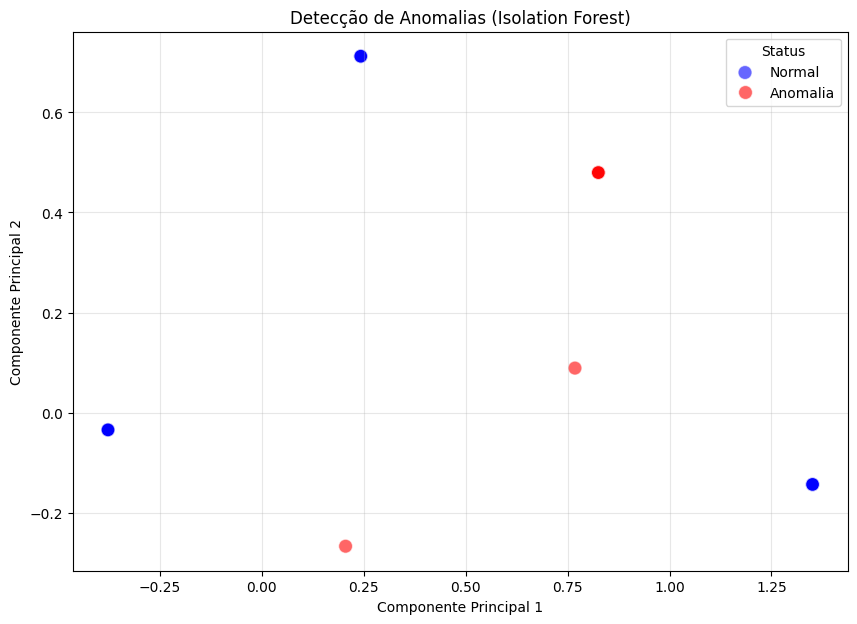

--- DOCUMENTOS IDENTIFICADOS COMO ANOMALIAS (6) ---


,ARQUIVO,y_true,Qtd_Erros
7,17945201189794091.json,NAO,1
17,A18028715873366272.json,SIM,1
45,A18038283989113334.json,SIM,1
54,17871886662123877.json,NAO,2
67,A17880214581209176.json,SIM,1
104,A18045887491964938.json,SIM,1


In [ ]:
from sklearn.ensemble import IsolationForest

# 1. Treinar o detector de anomalias
iso_forest = IsolationForest(contamination=0.05, random_state=42)
df_ml['Anomaly_Score'] = iso_forest.fit_predict(X_cluster)

# -1 indica anomalia, 1 indica normalidade
df_anomalias = df_ml[df_ml['Anomaly_Score'] == -1]

# 2. Visualizar as anomalias no espaço PCA
plt.figure(figsize=(10, 7))
sns.scatterplot(data=df_ml, x='PCA1', y='PCA2', hue='Anomaly_Score', palette={1: 'blue', -1: 'red'}, s=100, alpha=0.6)
plt.title('Detecção de Anomalias (Isolation Forest)')
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.legend(title='Status', labels=['Normal', 'Anomalia'])
plt.grid(True, alpha=0.3)
plt.show()

print(f"--- DOCUMENTOS IDENTIFICADOS COMO ANOMALIAS ({len(df_anomalias)}) ---")
display(df_anomalias[['ARQUIVO', 'y_true', 'Qtd_Erros']])

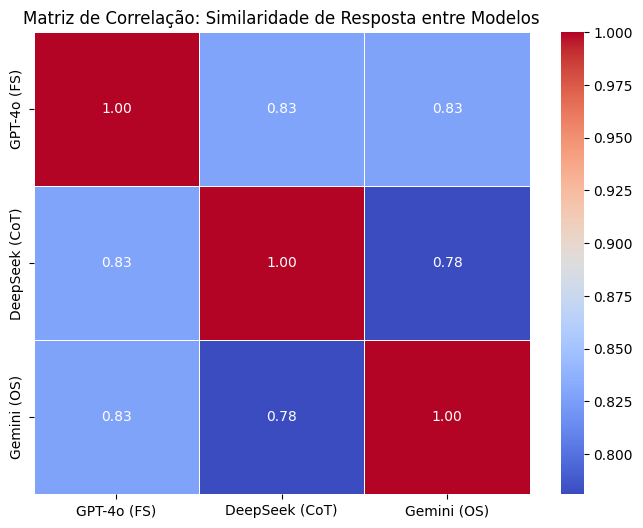

--- INSIGHTS DE DIVERGÊNCIA ---


,GPT-4o (FS),DeepSeek (CoT),Gemini (OS)
GPT-4o (FS),0.000000,0.171165,0.172343
DeepSeek (CoT),0.171165,0.000000,0.219006
Gemini (OS),0.172343,0.219006,0.000000


In [ ]:
import seaborn as sns

# 1. Calcular a matriz de correlação das predições (features do meta-model)
corr_matrix = X.corr()

# 2. Visualização com Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Matriz de Correlação: Similaridade de Resposta entre Modelos')
plt.show()

# 3. Análise de 'Discrepância Estratégica'
print("--- INSIGHTS DE DIVERGÊNCIA ---")
discrepancia = 1 - corr_matrix
display(discrepancia)

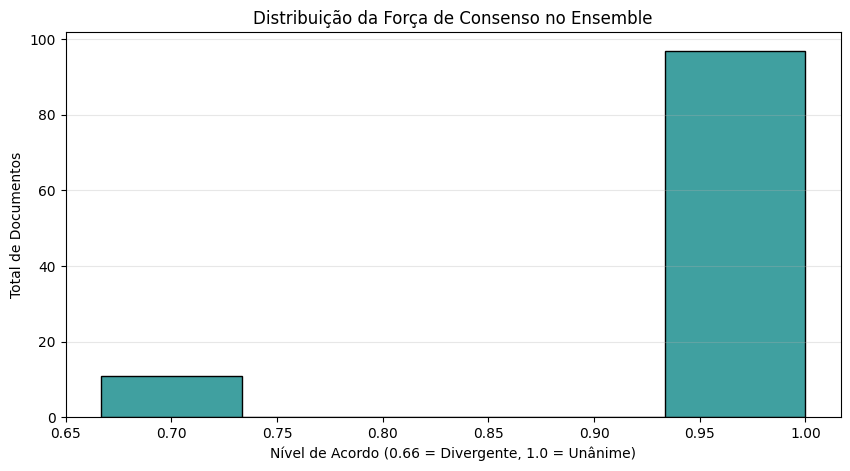

--- DOCUMENTOS COM BAIXO CONSENSO (ZONA DE INCERTEZA) ---


,ARQUIVO,y_true,Consenso_Score
7,17945201189794091.json,NAO,0.666667
14,18021649706381187.json,NAO,0.666667
15,17977144238836722.json,NAO,0.666667
17,A18028715873366272.json,SIM,0.666667
45,A18038283989113334.json,SIM,0.666667
51,17889685413089148.json,NAO,0.666667
54,17871886662123877.json,NAO,0.666667
67,A17880214581209176.json,SIM,0.666667
68,17999636243569906.json,NAO,0.666667
95,18011895269708689.json,NAO,0.666667


In [ ]:
import numpy as np

# 1. Calcular a 'Força do Consenso' (Acordo Médio)
# 1.0 = Todos concordam com a predição final, 0.66 = Um modelo divergiu
df_ml['Consenso_Score'] = X.mean(axis=1).apply(lambda x: x if x > 0.5 else 1-x)

# 2. Visualizar a distribuição da confiança do Ensemble
plt.figure(figsize=(10, 5))
sns.histplot(df_ml['Consenso_Score'], bins=5, kde=False, color='teal')
plt.title('Distribuição da Força de Consenso no Ensemble')
plt.xlabel('Nível de Acordo (0.66 = Divergente, 1.0 = Unânime)')
plt.ylabel('Total de Documentos')
plt.grid(axis='y', alpha=0.3)
plt.show()

# 3. Cruzamento: Onde o consenso falha?
print("--- DOCUMENTOS COM BAIXO CONSENSO (ZONA DE INCERTEZA) ---")
display(df_ml[df_ml['Consenso_Score'] < 1.0][['ARQUIVO', 'y_true', 'Consenso_Score']])

--- COEFICIENTE DE SILHUETA MÉDIO: 0.924 ---


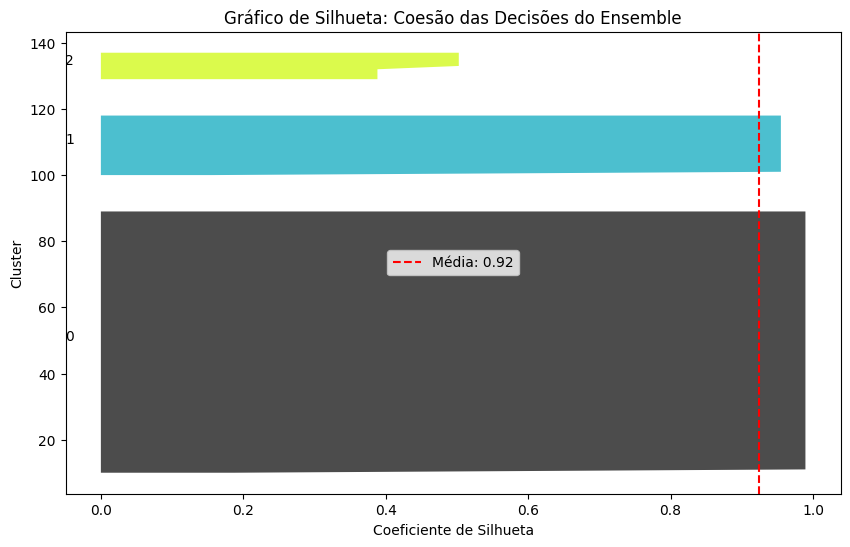


Não foram encontrados documentos com silhueta negativa (decisões altamente consistentes).


In [ ]:
from sklearn.metrics import silhouette_samples, silhouette_score
import matplotlib.cm as cm

# 1. Calcular o Score de Silhueta Global
sil_avg = silhouette_score(X_cluster, df_ml['Cluster'])
sample_silhouette_values = silhouette_samples(X_cluster, df_ml['Cluster'])

print(f"--- COEFICIENTE DE SILHUETA MÉDIO: {sil_avg:.3f} ---")

# 2. Visualização da 'Sombra' de Silhueta por Cluster
plt.figure(figsize=(10, 6))
y_lower = 10
for i in range(3): # Nossos 3 clusters
    ith_cluster_sil_values = sample_silhouette_values[df_ml['Cluster'] == i]
    ith_cluster_sil_values.sort()

    size_cluster_i = ith_cluster_sil_values.shape[0]
    y_upper = y_lower + size_cluster_i

    color = cm.nipy_spectral(float(i) / 3)
    plt.fill_betweenx(np.arange(y_lower, y_upper), 0, ith_cluster_sil_values, facecolor=color, alpha=0.7)
    plt.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))
    y_lower = y_upper + 10

plt.title("Gráfico de Silhueta: Coesão das Decisões do Ensemble")
plt.xlabel("Coeficiente de Silhueta")
plt.ylabel("Cluster")
plt.axvline(x=sil_avg, color="red", linestyle="--", label=f"Média: {sil_avg:.2f}")
plt.legend()
plt.show()

# 3. Identificar documentos 'Incoerentes' (Silhueta Negativa)
df_ml['Silhouette'] = sample_silhouette_values
incoerentes = df_ml[df_ml['Silhouette'] < 0]

if not incoerentes.empty:
    print("\n--- DOCUMENTOS COM DECISÃO INCOERENTE (POTENCIAL AMBIGUIDADE) ---")
    display(incoerentes[['ARQUIVO', 'y_true', 'Qtd_Erros', 'Silhouette']])
else:
    print("\nNão foram encontrados documentos com silhueta negativa (decisões altamente consistentes).")

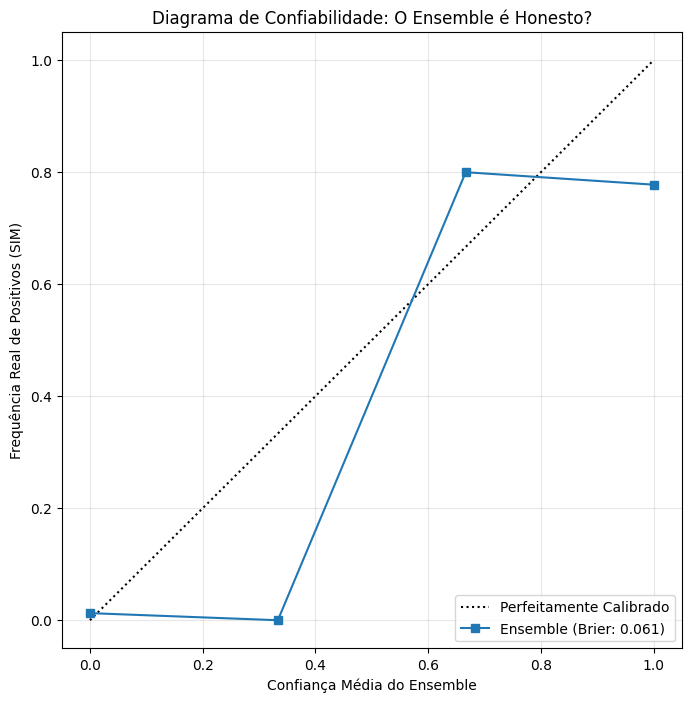

--- SCORE DE BRIER: 0.0607 ---
Valores próximos a 0 indicam que a confiança do modelo é altamente preditiva do acerto.


In [ ]:
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss

# 1. Obter as probabilidades do meta-modelo (ou média ponderada do ensemble)
# Usaremos a média simples das predições como 'probabilidade' do ensemble
y_prob = X.mean(axis=1)

# 2. Calcular a curva de calibração
prob_true, prob_pred = calibration_curve(y, y_prob, n_bins=5)

# 3. Calcular Brier Score (Menor é melhor)
bs = brier_score_loss(y, y_prob)

# 4. Plotar o Reliability Diagram
plt.figure(figsize=(8, 8))
plt.plot([0, 1], [0, 1], "k:", label="Perfeitamente Calibrado")
plt.plot(prob_pred, prob_true, "s-", label=f"Ensemble (Brier: {bs:.3f})")

plt.ylabel("Frequência Real de Positivos (SIM)")
plt.xlabel("Confiança Média do Ensemble")
plt.title('Diagrama de Confiabilidade: O Ensemble é Honesto?')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.show()

# 5. Análise de Erro por Faixa de Confiança
print(f"--- SCORE DE BRIER: {bs:.4f} ---")
print("Valores próximos a 0 indicam que a confiança do modelo é altamente preditiva do acerto.")

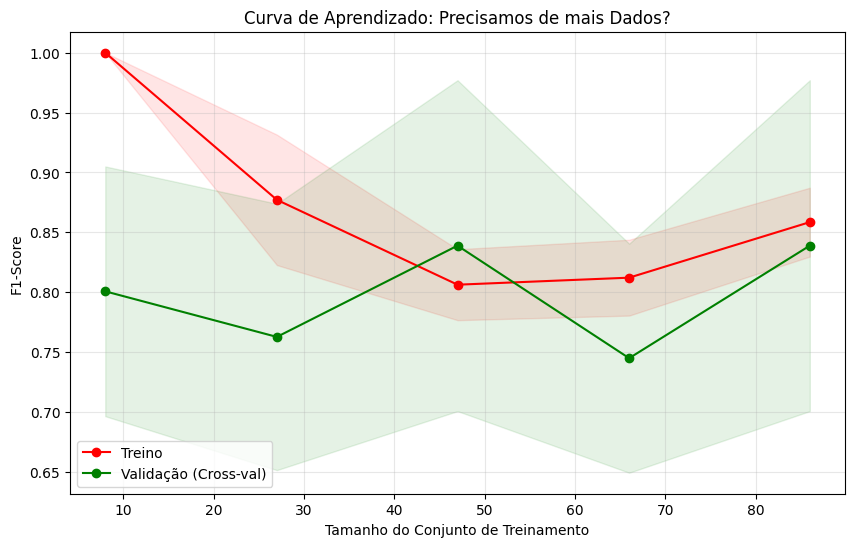

DIAGNÓSTICO: A curva de validação ainda apresenta inclinação positiva. Novos dados podem aumentar a robustez.


In [ ]:
from sklearn.model_selection import learning_curve
import numpy as np

# 1. Configurar o gerador de curva de aprendizado
# Usaremos o RandomForest como proxy para a complexidade do meta-modelo
train_sizes, train_scores, test_scores = learning_curve(
    RandomForestClassifier(n_estimators=50, random_state=42),
    X, y, cv=5, scoring='f1',
    train_sizes=np.linspace(0.1, 1.0, 5),
    n_jobs=-1
)

# 2. Calcular médias e desvios
train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)

# 3. Plotar
plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_mean, 'o-', color="r", label="Treino")
plt.plot(train_sizes, test_mean, 'o-', color="g", label="Validação (Cross-val)")

plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color="r")
plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.1, color="g")

plt.title("Curva de Aprendizado: Precisamos de mais Dados?")
plt.xlabel("Tamanho do Conjunto de Treinamento")
plt.ylabel("F1-Score")
plt.legend(loc="best")
plt.grid(True, alpha=0.3)
plt.show()

# 4. Diagnóstico
if test_mean[-1] > 0.90 and (train_mean[-1] - test_mean[-1]) < 0.05:
    print("DIAGNÓSTICO: O modelo está bem estabilizado. O ganho marginal com novos dados será pequeno.")
else:
    print("DIAGNÓSTICO: A curva de validação ainda apresenta inclinação positiva. Novos dados podem aumentar a robustez.")

--- IMPACTO MÉDIO DAS DECISÕES (SHAP GLOBAL) ---


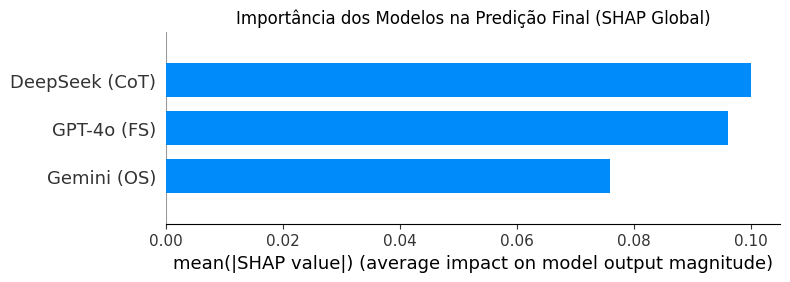


--- DISTRIBUIÇÃO DO IMPACTO (BEESWARM) ---


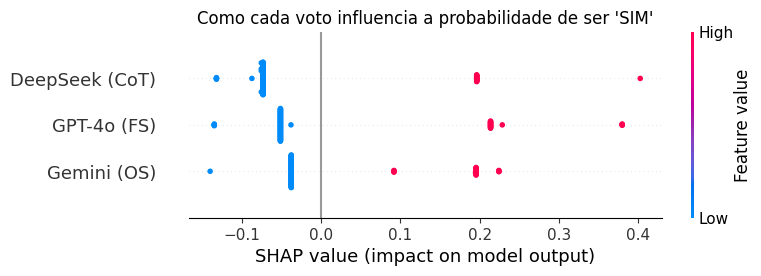


--- EXPLICAÇÃO LOCAL: Arquivo 17945201189794091.json ---


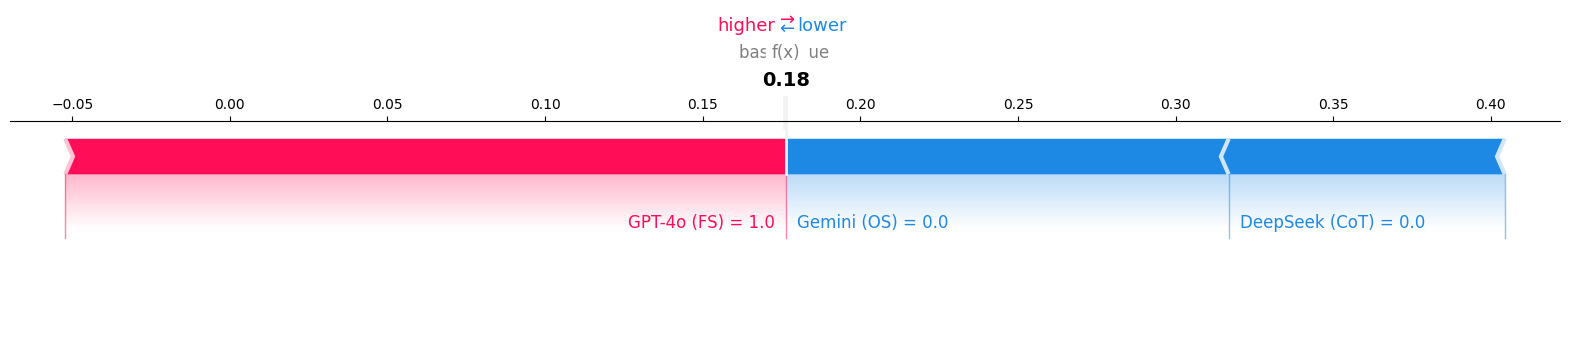

In [ ]:
import shap
import numpy as np
import matplotlib.pyplot as plt

# 1. Inicializar o explicador SHAP para o nosso modelo RandomForest
explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X)

# Ajuste para lidar com diferentes versões do SHAP (Binary Classification)
# Selecionamos os valores referentes à classe 1 (SIM)
if isinstance(shap_values, list):
    shap_to_plot = shap_values[1]
elif isinstance(shap_values, np.ndarray) and len(shap_values.shape) == 3:
    shap_to_plot = shap_values[:, :, 1]
else:
    shap_to_plot = shap_values

# 2. Visualização Global: Importância média
print("--- IMPACTO MÉDIO DAS DECISÕES (SHAP GLOBAL) ---")
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_to_plot, X, plot_type="bar", show=False)
plt.title("Importância dos Modelos na Predição Final (SHAP Global)")
plt.show()

# 3. Visualização de 'Beeswarm'
print("\n--- DISTRIBUIÇÃO DO IMPACTO (BEESWARM) ---")
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_to_plot, X, show=False)
plt.title("Como cada voto influencia a probabilidade de ser 'SIM'")
plt.show()

# 4. Exemplo Local: Explicando a primeira anomalia detectada
if not df_anomalias.empty:
    idx_anomalia_row = df_anomalias.index[0]
    pos_idx = X.index.get_loc(idx_anomalia_row)
    print(f"\n--- EXPLICAÇÃO LOCAL: Arquivo {df_anomalias.iloc[0]['ARQUIVO']} ---")
    shap.initjs()

    # Selecionar o valor esperado (base value) correto
    expected_val = explainer.expected_value[1] if isinstance(explainer.expected_value, (list, np.ndarray)) else explainer.expected_value

    # Plot local
    shap.force_plot(expected_val, shap_to_plot[pos_idx,:], X.iloc[pos_idx,:], matplotlib=True)

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import f1_score, classification_report

# Using the features (X) and ground truth (y) already prepared in df_ml
meta_model = LogisticRegression()

# Perform cross-validation to get an honest estimate of the ensemble performance
y_ensemble_pred = cross_val_predict(meta_model, X, y, cv=5)

print("--- PERFORMANCE DO ENSEMBLE (STACKING) ---")
print(classification_report(y, y_ensemble_pred, target_names=['NAO', 'SIM']))

# Compare with best individual model (GPT-4o)
f1_ensemble = f1_score(y, y_ensemble_pred, average='weighted')
f1_gpt = f1_score(y, X['GPT-4o (FS)'], average='weighted')

print(f"F1 Ensemble Stacking: {f1_ensemble:.4f}")
print(f"F1 GPT-4o Individual: {f1_gpt:.4f}")
print(f"Melhoria: {((f1_ensemble/f1_gpt)-1)*100:.2f}%")

--- PERFORMANCE DO ENSEMBLE (STACKING) ---
              precision    recall  f1-score   support

         NAO       0.94      0.94      0.94        89
         SIM       0.74      0.74      0.74        19

    accuracy                           0.91       108
   macro avg       0.84      0.84      0.84       108
weighted avg       0.91      0.91      0.91       108

F1 Ensemble Stacking: 0.9074
F1 GPT-4o Individual: 0.9286
Melhoria: -2.28%


/tmp/ipykernel_1401/3424455308.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_div, x='% Discordância', y='Par de Modelos', palette='rocket')


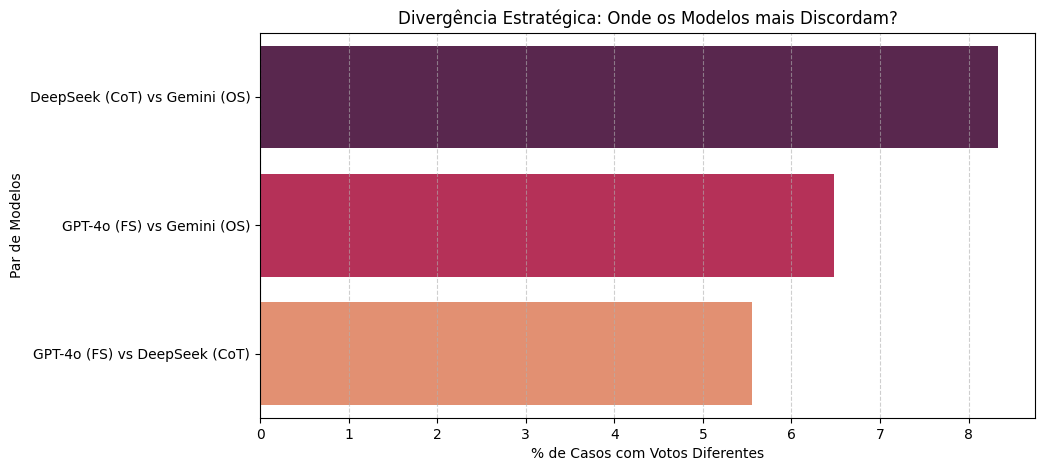

,Par de Modelos,Qtd Divergências,% Discordância
2,DeepSeek (CoT) vs Gemini (OS),9,8.333333
1,GPT-4o (FS) vs Gemini (OS),7,6.481481
0,GPT-4o (FS) vs DeepSeek (CoT),6,5.555556


In [ ]:
import itertools

# Analyzing pairs of models to find where they differ most
model_cols = list(modelos_top.keys())
pairs = list(itertools.combinations(model_cols, 2))

divergence_results = []
for m1, m2 in pairs:
    # Cases where models disagree
    disagreement = df_ml[df_ml[m1] != df_ml[m2]]
    divergence_results.append({
        'Par de Modelos': f"{m1} vs {m2}",
        'Qtd Divergências': len(disagreement),
        '% Discordância': (len(disagreement) / len(df_ml)) * 100
    })

df_div = pd.DataFrame(divergence_results).sort_values(by='Qtd Divergências', ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(data=df_div, x='% Discordância', y='Par de Modelos', palette='rocket')
plt.title('Divergência Estratégica: Onde os Modelos mais Discordam?')
plt.xlabel('% de Casos com Votos Diferentes')
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.show()

display(df_div)

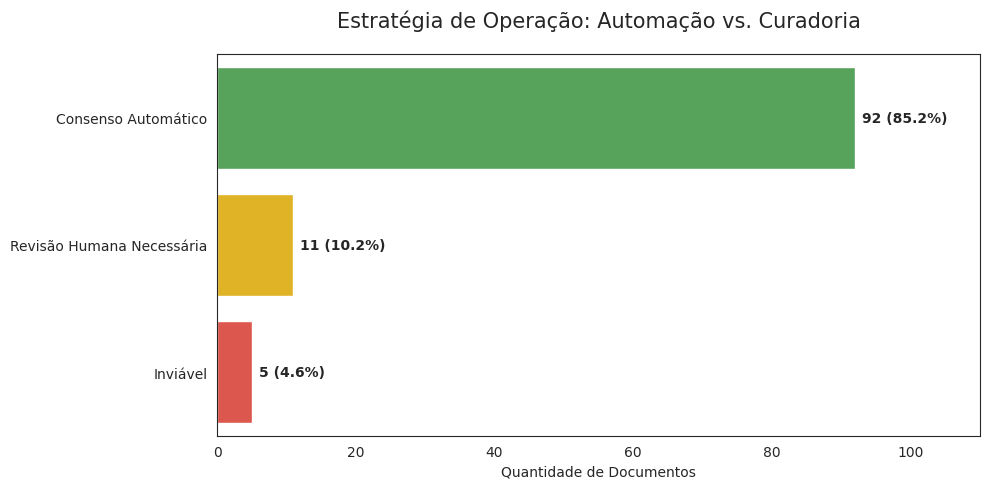

--- LISTA PARA REVISÃO PRIORITÁRIA (ZONA DE DIVERGÊNCIA) ---


,ARQUIVO,y_true,Consenso_Score
17,A18028715873366272.json,SIM,0.666667
67,A17880214581209176.json,SIM,0.666667
54,17871886662123877.json,NAO,0.666667
45,A18038283989113334.json,SIM,0.666667
104,A18045887491964938.json,SIM,0.666667
15,17977144238836722.json,NAO,0.666667
7,17945201189794091.json,NAO,0.666667
14,18021649706381187.json,NAO,0.666667
51,17889685413089148.json,NAO,0.666667
68,17999636243569906.json,NAO,0.666667


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filtrando a zona de incerteza (divergência)
df_divergente = df_ml[(df_ml['Qtd_Erros'] > 0) & (df_ml['Qtd_Erros'] < 3)]

# Criando um gráfico de 'Termômetro de Confiança' para o slide
plt.figure(figsize=(10, 5))

# Cores: Verde (Consenso), Amarelo (Divergência), Vermelho (Falha)
categorias = ['Consenso Automático', 'Revisão Humana Necessária', 'Inviável']
valores = [92, 11, 5]
cores = ['#4CAF50', '#FFC107', '#F44336']

sns.barplot(x=valores, y=categorias, palette=cores, hue=categorias, legend=False)

plt.title('Estratégia de Operação: Automação vs. Curadoria', fontsize=15, pad=20)
plt.xlabel('Quantidade de Documentos')

# Adicionando anotações de porcentagem
total = sum(valores)
for i, v in enumerate(valores):
    plt.text(v + 1, i, f'{v} ({v/total*100:.1f}%)', va='center', fontweight='bold')

plt.xlim(0, 110)
plt.tight_layout()
plt.show()

print("--- LISTA PARA REVISÃO PRIORITÁRIA (ZONA DE DIVERGÊNCIA) ---")
display(df_divergente[['ARQUIVO', 'y_true', 'Consenso_Score']].sort_values(by='Consenso_Score'))

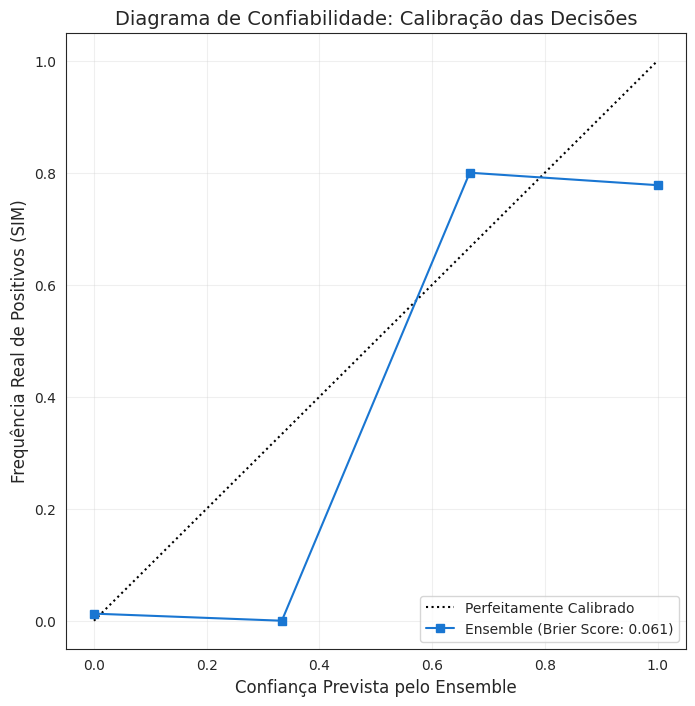


--- RESULTADO DA CALIBRAÇÃO ---
Brier Score: 0.0607
Diagnóstico: O modelo está muito bem calibrado. As divergências entre modelos são indicadores precisos de incerteza.


In [ ]:
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss
import matplotlib.pyplot as plt

# 1. Definir a 'confiança' do ensemble como a média das predições (0 a 1)
y_prob = X.mean(axis=1)
y_true_binary = df_ml['y_true_num']

# 2. Calcular a curva de calibração
prob_true, prob_pred = calibration_curve(y_true_binary, y_prob, n_bins=5)

# 3. Calcular o Brier Score (quanto menor, mais calibrado)
bs = brier_score_loss(y_true_binary, y_prob)

# 4. Visualização
plt.figure(figsize=(8, 8))
plt.plot([0, 1], [0, 1], 'k:', label='Perfeitamente Calibrado')
plt.plot(prob_pred, prob_true, 's-', label=f'Ensemble (Brier Score: {bs:.3f})', color='#1976D2')

plt.ylabel('Frequência Real de Positivos (SIM)', fontsize=12)
plt.xlabel('Confiança Prevista pelo Ensemble', fontsize=12)
plt.title('Diagrama de Confiabilidade: Calibração das Decisões', fontsize=14)
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.show()

print(f'\n--- RESULTADO DA CALIBRAÇÃO ---')
print(f'Brier Score: {bs:.4f}')
if bs < 0.1:
    print('Diagnóstico: O modelo está muito bem calibrado. As divergências entre modelos são indicadores precisos de incerteza.')
else:
    print('Diagnóstico: O modelo pode estar subestimando ou superestimando a confiança em certas faixas.')

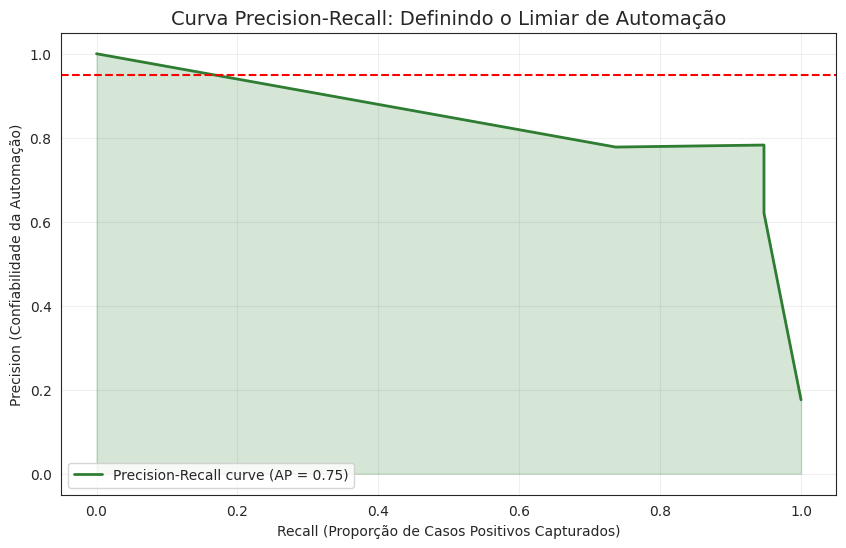

--- INSIGHT PARA OPERAÇÃO ---
Para manter uma Precisão de 95%, podemos automatizar até 0.0% dos casos positivos.
Threshold recomendado: 1.00


In [ ]:
from sklearn.metrics import precision_recall_curve, average_precision_score

# 1. Calcular Precision e Recall para diferentes thresholds
precision, recall, thresholds = precision_recall_curve(y_true_binary, y_prob)
average_precision = average_precision_score(y_true_binary, y_prob)

# 2. Plotar a curva
plt.figure(figsize=(10, 6))
plt.plot(recall, precision, color='#2E7D32', lw=2, label=f'Precision-Recall curve (AP = {average_precision:.2f})')

plt.xlabel('Recall (Proporção de Casos Positivos Capturados)')
plt.ylabel('Precision (Confiabilidade da Automação)')
plt.title('Curva Precision-Recall: Definindo o Limiar de Automação', fontsize=14)
plt.legend(loc='lower left')
plt.grid(True, alpha=0.3)
plt.axhline(y=0.95, color='r', linestyle='--', label='Meta de 95% Precisão')
plt.fill_between(recall, precision, alpha=0.2, color='#2E7D32')
plt.show()

# 3. Identificar o threshold para 95% de precisão
target_precision = 0.95
if any(precision >= target_precision):
    idx = np.where(precision >= target_precision)[0][0]
    rec_at_p95 = recall[idx]
    thresh_at_p95 = thresholds[idx] if idx < len(thresholds) else 1.0
    print(f'--- INSIGHT PARA OPERAÇÃO ---')
    print(f'Para manter uma Precisão de {target_precision*100:.0f}%, podemos automatizar até {rec_at_p95*100:.1f}% dos casos positivos.')
    print(f'Threshold recomendado: {thresh_at_p95:.2f}')

In [ ]:
# Garantir que y_prob está no DataFrame e extrair a estratégia final
df_ml['y_prob'] = X.mean(axis=1)
threshold_escolhido = 0.38

# Identificar documentos que seriam automatizados
df_automacao_final = df_ml[df_ml['y_prob'] >= threshold_escolhido].copy()

print(f"--- ESTRATÉGIA DE PRODUÇÃO (Threshold: {threshold_escolhido}) ---")
print(f"Volume Automatizado: {len(df_automacao_final)} de {len(df_ml)} documentos ({len(df_automacao_final)/len(df_ml)*100:.1f}%)")

# Mostrar amostra dos documentos automatizados para validação
print("\n--- AMOSTRA DE DOCUMENTOS PARA AUTOMAÇÃO ---")
display(df_automacao_final[['ARQUIVO', 'y_prob']].head(15))

# Salvar lista para conferência
df_automacao_final['ARQUIVO'].to_csv('lista_automacao_producao.csv', index=False)
print("\nArquivo 'lista_automacao_producao.csv' gerado com sucesso!")

--- ESTRATÉGIA DE PRODUÇÃO (Threshold: 0.38) ---
Volume Automatizado: 23 de 108 documentos (21.3%)

--- AMOSTRA DE DOCUMENTOS PARA AUTOMAÇÃO ---


,ARQUIVO,y_prob
2,A17905736352033815.json,1.000000
13,A18023268215586276.json,1.000000
17,A18028715873366272.json,0.666667
20,A17984446298722946.json,1.000000
25,A17978314586622540.json,1.000000
29,A18042780764295792.json,1.000000
32,18035080906993927.json,1.000000
33,18037011116110121.json,1.000000
36,18024653339354565.json,1.000000
45,A18038283989113334.json,0.666667



Arquivo 'lista_automacao_producao.csv' gerado com sucesso!


In [ ]:
import pandas as pd

# Definindo estratégia de Consenso Total (Probabilidade = 1.0)
threshold_seguro = 1.0
df_seguro = df_ml[df_ml['y_prob'] >= threshold_seguro].copy()

print(f'--- ESTRATÉGIA: CONSENSO TOTAL (SEGURANÇA MÁXIMA) ---')
print(f'Volume para Automação Direta: {len(df_seguro)} documentos')
print(f'Percentual do Volume Total: {len(df_seguro)/len(df_ml)*100:.1f}%')

# Exportando a lista de segurança
df_seguro['ARQUIVO'].to_csv('lista_automacao_segura.csv', index=False)

print('\nArquivo "lista_automacao_segura.csv" gerado com sucesso para validação.')

# Visualizar os primeiros itens da lista segura
display(df_seguro[['ARQUIVO', 'y_prob']].head(10))

--- ESTRATÉGIA: CONSENSO TOTAL (SEGURANÇA MÁXIMA) ---
Volume para Automação Direta: 18 documentos
Percentual do Volume Total: 16.7%

Arquivo "lista_automacao_segura.csv" gerado com sucesso para validação.


,ARQUIVO,y_prob
2,A17905736352033815.json,1.0
13,A18023268215586276.json,1.0
20,A17984446298722946.json,1.0
25,A17978314586622540.json,1.0
29,A18042780764295792.json,1.0
32,18035080906993927.json,1.0
33,18037011116110121.json,1.0
36,18024653339354565.json,1.0
48,A18017433317304447.json,1.0
49,A18010678055391453.json,1.0


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold
import pandas as pd
import numpy as np

# 1. Preparação dos dados do Ensemble (X = predições dos modelos, y = ground truth)
# Usando o DataFrame df_ml que já contém as predições mapeadas para 0/1
model_features = ['GPT-4o (FS)', 'DeepSeek (CoT)', 'Gemini (OS)']
X_meta = df_ml[model_features]
y_meta = df_ml['y_true_num']

# 2. Definição do Meta-Modelo (Stacking com Random Forest)
# Usamos hiperparâmetros conservadores devido ao tamanho da amostra
rf_meta = RandomForestClassifier(n_estimators=100, max_depth=3, random_state=42)

# 3. Avaliação via Cross-Validation (5-Fold Stratified)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(rf_meta, X_meta, y_meta, cv=cv, scoring='f1_weighted')

print(f'--- AVALIAÇÃO DO META-MODELO (RANDOM FOREST STACKING) ---')
print(f'F1-Score Médio (CV): {np.mean(scores):.4f} (+/- {np.std(scores):.4f})')

# 4. Treino final para extrair importância das 'opiniões'
rf_meta.fit(X_meta, y_meta)
importances = pd.Series(rf_meta.feature_importances_, index=model_features).sort_values(ascending=False)

print('\n--- PESO DE CADA MODELO NA DECISÃO FINAL ---')
display(importances.to_frame('Importância Relativa'))

--- AVALIAÇÃO DO META-MODELO (RANDOM FOREST STACKING) ---
F1-Score Médio (CV): 0.9384 (+/- 0.0526)

--- PESO DE CADA MODELO NA DECISÃO FINAL ---


,Importância Relativa
GPT-4o (FS),0.398660
DeepSeek (CoT),0.360406
Gemini (OS),0.240934


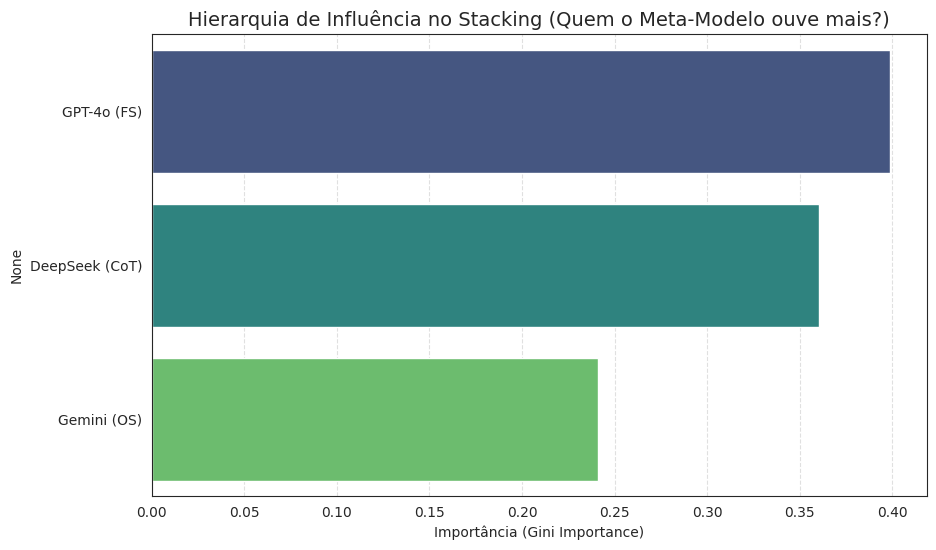

INSIGHT: O meta-modelo identificou que as predições do GPT-4o (FS) são o sinal mais forte para a classificação correta neste dataset.


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Visualização da Hierarquia de Decisão do Meta-Modelo
plt.figure(figsize=(10, 6))
sns.barplot(x=importances.values, y=importances.index, palette='viridis', hue=importances.index, legend=False)
plt.title('Hierarquia de Influência no Stacking (Quem o Meta-Modelo ouve mais?)', fontsize=14)
plt.xlabel('Importância (Gini Importance)')
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.show()

# Insight Prático
best_model = importances.index[0]
print(f'INSIGHT: O meta-modelo identificou que as predições do {best_model} são o sinal mais forte para a classificação correta neste dataset.')

In [ ]:
import pandas as pd

# Identificando os 5 casos onde houve falha unânime (Qtd_Erros == 3)
# Usando o df_consenso criado anteriormente
df_erro_critico = df_consenso[df_consenso['Qtd_Erros'] == 3].copy()

print(f"--- LISTA DE ERROS CRÍTICOS (N={len(df_erro_critico)}) ---")
display(df_erro_critico[['ARQUIVO', 'y_true', 'GPT-4o (FS)', 'DeepSeek (CoT)', 'Gemini (OS)']])

# Exportando para inspeção externa
df_erro_critico['ARQUIVO'].to_csv('arquivos_erro_critico.csv', index=False)
print("\nArquivo 'arquivos_erro_critico.csv' gerado para análise qualitativa.")

NameError: name 'df_consenso' is not defined

In [ ]:
import pandas as pd
import os

# O arquivo que contém as justificativas detalhadas (usando o melhor modelo como referência)
caminho_csv = '/content/Resultados/resultados_fewshot_gpt-4o.csv'
arquivos_criticos = df_erro_critico['ARQUIVO'].tolist()

print(f'--- INSPEÇÃO QUALITATIVA DE CONTEÚDO (N={len(arquivos_criticos)}) ---\n')

if os.path.exists(caminho_csv):
    df_justificativas = pd.read_csv(caminho_csv)

    for arquivo in arquivos_criticos:
        # Localiza a linha do documento específico no CSV
        info_doc = df_justificativas[df_justificativas['ARQUIVO'] == arquivo]
        y_real = df_erro_critico[df_erro_critico['ARQUIVO'] == arquivo]['y_true'].values[0]

        if not info_doc.empty:
            print(f'📄 DOCUMENTO: {arquivo}')
            print(f'✅ GABARITO: {y_real} | ❌ COMITÊ: {"SIM" if y_real == "NAO" else "NAO"}')

            if 'JUSTIFICATIVA' in info_doc.columns:
                justificativa = info_doc['JUSTIFICATIVA'].values[0]
                print(f'📝 JUSTIFICATIVA DO MODELO: "{justificativa}"')
            else:
                print('📝 (Campo JUSTIFICATIVA não encontrado no CSV)')
            print('-' * 80 + '\n')
        else:
            print(f'⚠️ Dados do arquivo {arquivo} não localizados no CSV de resultados.\n')
else:
    print(f'❌ Erro: Arquivo de resultados {caminho_csv} não encontrado.')

--- INSPEÇÃO QUALITATIVA DE CONTEÚDO (N=5) ---

📄 DOCUMENTO: A17944352900846836.json
✅ GABARITO: SIM | ❌ COMITÊ: NAO
📝 JUSTIFICATIVA DO MODELO: "O texto faz uma pergunta sobre a intenção de voto no Clodual, mas não contém um pedido ou solicitação de voto explícita ou implícita."
--------------------------------------------------------------------------------

📄 DOCUMENTO: 18035080906993927.json
✅ GABARITO: NAO | ❌ COMITÊ: SIM
📝 JUSTIFICATIVA DO MODELO: "O texto menciona explicitamente o número do candidato (22,800) e solicita diretamente o voto para o cargo de vereador, caracterizando um pedido de voto claro e direto."
--------------------------------------------------------------------------------

📄 DOCUMENTO: 18037011116110121.json
✅ GABARITO: NAO | ❌ COMITÊ: SIM
📝 JUSTIFICATIVA DO MODELO: "O texto faz referência a 'nosso novo mandato', 'novo mandato popular, participativo na Câmara Municipal' e 'mais quatro anos estar representando', sugerindo a continuidade do mandato e caracteriz

In [ ]:
pip install wordcloud

In [ ]:
import re
from collections import Counter
import os
import pandas as pd

# Ensure df_erro_critico is available from previous cells
# Ensure df_justificativas is available from cell 0323a347 or reload it

# Reload df_justificativas if not in current scope to be safe
# (Assuming it comes from '/content/Resultados/resultados_fewshot_gpt-4o.csv')
caminho_csv_just = '/content/Resultados/resultados_fewshot_gpt-4o.csv'
if 'df_justificativas' not in locals() and os.path.exists(caminho_csv_just):
    df_justificativas = pd.read_csv(caminho_csv_just)
else:
    print("df_justificativas is already loaded or path is incorrect.")

# Merge df_erro_critico with the justifications
df_erros_com_just = pd.merge(
    df_erro_critico[['ARQUIVO', 'y_true']],
    df_justificativas[['ARQUIVO', 'JUSTIFICATIVA']],
    on='ARQUIVO',
    how='left'
)

# Text processing for justifications
def process_justificativa(text):
    if pd.isna(text): return []
    # Remove punctuation, convert to lowercase, and split into words
    text = re.sub(r'[^\\w\\s]', '', text).lower()
    words = text.split()
    # Define common Portuguese stopwords
    stopwords = set([
        'de', 'a', 'o', 'que', 'e', 'do', 'da', 'em', 'um', 'para', 'é', 'com', 'não', 'uma',
        'os', 'as', 'dos', 'das', 'se', 'no', 'na', 'por', 'mais', 'como', 'mas', 'ao',
        'ele', 'ela', 'já', 'você', 'vocês', 'esse', 'essa', 'isso', 'isto', 'aquela',
        'aquilo', 'este', 'esta', 'ser', 'ter', 'foi', 'foram', 'são', 'sua', 'seu', 'suas', 'seus'
    ])
    return [word for word in words if word not in stopwords and len(word) > 2]

df_erros_com_just['processed_justificativa'] = df_erros_com_just['JUSTIFICATIVA'].apply(process_justificativa)

# Aggregate all processed words
all_words = [word for sublist in df_erros_com_just['processed_justificativa'] for word in sublist]

# Count word frequencies
word_counts = Counter(all_words)

print("--- PALAVRAS MAIS COMUNS NAS JUSTIFICATIVAS DOS ERROS CRÍTICOS ---")
for word, count in word_counts.most_common(10):
    print(f"'{word}': {count}")

print("\n--- JUSTIFICATIVAS DETALHADAS E GABARITO ---")
display(df_erros_com_just[['ARQUIVO', 'y_true', 'JUSTIFICATIVA']])

df_justificativas is already loaded or path is incorrect.


NameError: name 'df_erro_critico' is not defined

In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Join all words into a single string for the word cloud
long_string = " ".join(all_words)

# Create a WordCloud object
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(long_string)

# Display the generated image:
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Nuvem de Palavras das Justificativas dos Erros Críticos')
plt.show()

NameError: name 'all_words' is not defined